In [201]:
import pandas as pd

df = pd.read_csv("../data/dataset_final.csv")
print(df.shape)
df.head()

(305, 18)


,Machine_ID,Machine_Name,Platform,Platform_ID,OS,OS_Detail,Difficulty,Difficulty_Numeric,Attack_Category,Attack_Category_Detail,Vulnerability_Type,Kill_Chain_Stages,Skills_Required,Learning_Objectives,Estimated_Time,Estimated_Time_Hours,Attack_Path_Length,Entry_Point
0,1,LAMPSecurity CTF 4,VulnHub,0,Linux,NaN,Easy,1,Web Exploitation,Web Exploitation,SQL Injection → Credential Extraction → Privil...,Recon → Exploitation → Credential Access → Pri...,Enumeration; Exploitation; Credential Extracti...,SQL Injection; Credential Extraction; Privileg...,<1 hour,0.5,5,SQL Injection (login/input parameter)
1,2,LAMPSecurity CTF 5,VulnHub,0,Linux,NaN,Easy,1,Web Exploitation,Web Exploitation,Local File Inclusion (LFI) → Credential Extrac...,Recon → Exploitation → Credential Access → Pri...,Enumeration; Exploitation; Credential Extracti...,Local File Inclusion; Credential Extraction; P...,1-2 hours,1.5,6,Local File Inclusion (web parameter)
2,3,LAMPSecurity CTF 7,VulnHub,0,Linux,NaN,Easy,1,Web Exploitation,Web Exploitation,SQL Injection → File Upload → Credential Extra...,Recon → Exploitation → Credential Access → Pri...,Enumeration; Exploitation; Credential Extracti...,SQL Injection; File Upload Exploitation; Crede...,1-2 hours,1.5,7,SQL Injection (authentication bypass)
3,4,HolyNix 1,VulnHub,0,Linux,NaN,Medium,2,Web Exploitation,Web Exploitation,SQL Injection → File Inclusion → Credential Ex...,Recon → Exploitation → Credential Access → Pri...,Enumeration; Exploitation; Credential Extracti...,SQL Injection; Local File Inclusion; Credentia...,2-3 hours,2.5,8,SQL Injection (web form)
4,5,pWnOS 1.0,VulnHub,0,Linux,NaN,Medium,2,Web Exploitation,Web Exploitation,Arbitrary File Disclosure → Credential Extract...,Recon → Exploitation → Credential Access → Pri...,Enumeration; Exploitation; Credential Extracti...,File Disclosure; Credential Extraction; Privil...,2-3 hours,2.5,7,Arbitrary File Disclosure (web endpoint)


In [202]:
#Checking for missing values
df.isnull().sum()

Machine_ID                 0
Machine_Name               0
Platform                   0
Platform_ID                0
OS                         0
OS_Detail                 67
Difficulty                 0
Difficulty_Numeric         0
Attack_Category            0
Attack_Category_Detail     0
Vulnerability_Type         0
Kill_Chain_Stages          0
Skills_Required            0
Learning_Objectives        0
Estimated_Time             0
Estimated_Time_Hours       0
Attack_Path_Length         0
Entry_Point                0
dtype: int64

In [203]:
#Fill missing OS_Detail values with empty string
df['OS_Detail'] = df['OS_Detail'].fillna('')
#Verify no missing value remains
df.isnull().sum()

Machine_ID                0
Machine_Name              0
Platform                  0
Platform_ID               0
OS                        0
OS_Detail                 0
Difficulty                0
Difficulty_Numeric        0
Attack_Category           0
Attack_Category_Detail    0
Vulnerability_Type        0
Kill_Chain_Stages         0
Skills_Required           0
Learning_Objectives       0
Estimated_Time            0
Estimated_Time_Hours      0
Attack_Path_Length        0
Entry_Point               0
dtype: int64

In [204]:
# Check basic statistics of numeric columns
# This helps us verify the values are in expected ranges
# Attack_Path_Length should be between 3-14
# Estimated_Time_Hours should be between 0.5-6
# Difficulty_Numeric should be 1, 2, or 3 only

df[['Attack_Path_Length', 'Estimated_Time_Hours', 
    'Difficulty_Numeric', 'Platform_ID']].describe()

,Attack_Path_Length,Estimated_Time_Hours,Difficulty_Numeric,Platform_ID
count,305.000000,305.000000,305.000000,305.000000
mean,9.311475,2.813934,2.216393,0.003279
std,1.937689,0.868876,0.658242,0.057260
min,3.000000,0.500000,1.000000,0.000000
25%,8.000000,2.500000,2.000000,0.000000
50%,9.000000,2.500000,2.000000,0.000000
75%,11.000000,3.500000,3.000000,0.000000
max,14.000000,5.500000,3.000000,1.000000


In [205]:
# Check how many machines are Easy, Medium and Hard

# If one class has very few machines, model may struggle to learn it

print("Difficulty distribution:")
print(df['Difficulty'].value_counts())
print()
print("As percentage:")
print(df['Difficulty'].value_counts(normalize=True).round(2) * 100)

Difficulty distribution:
Difficulty
Medium    159
Hard      106
Easy       40
Name: count, dtype: int64

As percentage:
Difficulty
Medium    52.0
Hard      35.0
Easy      13.0
Name: proportion, dtype: float64


In [206]:
# Check distribution of attack categories
# We want to see if all 6 categories are well represented
# This affects how well our recommender can match student preferences

print("Attack Category distribution:")
print(df['Attack_Category'].value_counts())

Attack Category distribution:
Attack_Category
Web Exploitation                 264
Network Exploitation              28
Mixed (Web + Network)              5
Binary Exploitation                3
Credential-Based Exploitation      3
Cryptographic Exploitation         2
Name: count, dtype: int64


In [207]:
# Check unique token counts for multi-value columns
# This tells us how large our feature matrix will be after encoding
# More unique tokens = more columns in X

print("Skills_Required unique tokens:")
from collections import Counter
import re

skills_tokens = []
for s in df['Skills_Required'].dropna():
    for sk in s.split(';'):
        skills_tokens.append(sk.strip())
print(f"  Total unique skills: {len(set(skills_tokens))}")

print("\nLearning_Objectives unique tokens:")
lo_tokens = []
for s in df['Learning_Objectives'].dropna():
    for lo in s.split(';'):
        lo_tokens.append(lo.strip())
print(f"  Total unique objectives: {len(set(lo_tokens))}")

print("\nKill_Chain_Stages unique tokens:")
kc_tokens = []
for s in df['Kill_Chain_Stages'].dropna():
    for kc in s.split('→'):
        kc_tokens.append(kc.strip())
print(f"  Total unique stages: {len(set(kc_tokens))}")

Skills_Required unique tokens:
  Total unique skills: 196

Learning_Objectives unique tokens:
  Total unique objectives: 197

Kill_Chain_Stages unique tokens:
  Total unique stages: 9


In [208]:
# Reset Machine_ID to be clean and continuous (1, 2, 3, ...)


df = df.reset_index(drop=True)
df['Machine_ID'] = df.index + 1

# Verify
print(f"Machine_ID range: {df['Machine_ID'].min()} to {df['Machine_ID'].max()}")
print(f"Total machines: {len(df)}")

Machine_ID range: 1 to 305
Total machines: 305


In [209]:
# IMPROVED IMPLICIT DIFFICULTY SCORE ────
#  combine effort + breadth + depth signals
# Complexity signals have different weights because:
#   Binary/ROP = deepest technical knowledge (0.35)
#   Crypto/Steg = problem solving depth (0.25)
#   Pivoting = multi-host thinking (0.25)
#   Multi-service = more attack surface (0.15)

# Count number of skills per machine
df['skills_count'] = df['Skills_Required'].fillna('').apply(
    lambda x: len([s for s in x.split(';') if s.strip()])
)

# Count number of kill chain stages per machine
df['stages_count'] = df['Kill_Chain_Stages'].fillna('').apply(
    lambda x: len([s for s in x.split('→') if s.strip()])
)

# Complexity signals using lowercase for safer matching
df['has_binary'] = df['Skills_Required'].str.lower().str.contains(
    'binary|rop|buffer overflow|exploit development', na=False
).astype(int)

df['has_crypto'] = df['Skills_Required'].str.lower().str.contains(
    'crypto|encoding|steganography|padding oracle', na=False
).astype(int)

df['has_pivot'] = df['Skills_Required'].str.lower().str.contains(
    'pivot|lateral|port forward|proxychains', na=False
).astype(int)

df['has_multi_service'] = df['Entry_Point'].str.lower().str.contains(
    'ftp|smb|nfs|snmp|irc', na=False
).astype(int)

# Weighted complexity score
# Binary weighted highest because it requires deepest technical knowledge
complexity_score = (
    0.35 * df['has_binary'] +
    0.25 * df['has_crypto'] +
    0.25 * df['has_pivot'] +
    0.15 * df['has_multi_service']
)

# Normalize count-based features to 0-1 range
from sklearn.preprocessing import MinMaxScaler
scaler_temp = MinMaxScaler()
df[['path_norm', 'skills_norm', 'stages_norm']] = scaler_temp.fit_transform(
    df[['Attack_Path_Length', 'skills_count', 'stages_count']]
)

# Final implicit difficulty score
df['implicit_difficulty'] = (
    0.3 * df['path_norm'] +        # effort
    0.3 * df['skills_norm'] +      # breadth
    0.1 * df['stages_norm'] +      # structure
    0.3 * complexity_score         # depth
)

# Sanity check — Hard should score higher than Easy
print("Average implicit difficulty by label:")
print(df.groupby('Difficulty')['implicit_difficulty'].mean().sort_values(ascending=False))
print()
print("Implicit difficulty stats:")
print(df['implicit_difficulty'].describe())

Average implicit difficulty by label:
Difficulty
Hard      0.535752
Medium    0.348863
Easy      0.152885
Name: implicit_difficulty, dtype: float64

Implicit difficulty stats:
count    305.000000
mean       0.388112
std        0.160843
min        0.021429
25%        0.251494
50%        0.448636
75%        0.492468
max        0.787857
Name: implicit_difficulty, dtype: float64


In [ ]:
#  ENCODING: Skills_Required (Multi-Value Column)
# Multi-Label Binarization.

from sklearn.preprocessing import MultiLabelBinarizer

# Initialize the encoder
mlb_skills = MultiLabelBinarizer()

# Step 1 — Convert each row into a list of skills
# - Handle missing values using fillna('')
# - Split on ';'
# - Strip whitespace
# - Remove empty values
skills_split = df['Skills_Required'].fillna('').apply(
    lambda x: [s.strip() for s in x.split(';') if s.strip()]
)

# Step 2 — Apply MultiLabelBinarizer
# This creates a binary matrix:
# rows = machines
# columns = unique skills
skills_encoded = pd.DataFrame(
    mlb_skills.fit_transform(skills_split),

    # Prefix each column with 'skill__' for clarity and consistency
    columns=[f"skill__{c}" for c in mlb_skills.classes_],

    # Keep index aligned with original dataframe 
)

# Step 3 — Inspect results
print(f"Skills encoded shape: {skills_encoded.shape}")
print(f"Sample skill columns: {list(skills_encoded.columns[:5])}")
print(f"Total unique skills: {len(mlb_skills.classes_)}")

Skills encoded shape: (305, 196)
Sample skill columns: ['skill__ADB Access', 'skill__API Enumeration', 'skill__Admin Access', 'skill__Application Access', 'skill__Application Discovery']
Total unique skills: 196


In [211]:
# Encode Learning_Objectives
# Same approach as Skills_Required — split on ; and binarize
mlb_objectives = MultiLabelBinarizer()
objectives_split = df['Learning_Objectives'].fillna('').apply(
    lambda x: [s.strip() for s in x.split(';') if s.strip()]
)
objectives_encoded = pd.DataFrame(
    mlb_objectives.fit_transform(objectives_split),
    columns=[f"obj__{c}" for c in mlb_objectives.classes_],
    index=df.index
)

print(f"Objectives encoded shape: {objectives_encoded.shape}")
print(f"Total unique objectives: {len(mlb_objectives.classes_)}")

Objectives encoded shape: (305, 197)
Total unique objectives: 197


In [212]:
# Encode Kill_Chain_Stages
# Split on → instead of ;
mlb_killchain = MultiLabelBinarizer()
killchain_split = df['Kill_Chain_Stages'].fillna('').apply(
    lambda x: [s.strip() for s in x.split('→') if s.strip()]
)
killchain_encoded = pd.DataFrame(
    mlb_killchain.fit_transform(killchain_split),
    columns=[f"stage__{c}" for c in mlb_killchain.classes_],
    index=df.index
)

print(f"Kill chain encoded shape: {killchain_encoded.shape}")
print(f"Total unique stages: {len(mlb_killchain.classes_)}")

Kill chain encoded shape: (305, 9)
Total unique stages: 9


In [213]:
# One-Hot encode single-value categorical columns
# Entry_Point and Vulnerability_Type included because
# students will input these as preferences in the recommender

attack_cat_encoded = pd.get_dummies(
    df['Attack_Category'].fillna('Unknown'), prefix='attack'
).astype(int)

os_encoded = pd.get_dummies(
    df['OS'].fillna('Unknown'), prefix='os'
).astype(int)

entry_encoded = pd.get_dummies(
    df['Entry_Point'].fillna('Unknown'), prefix='entry'
).astype(int)

vuln_encoded = pd.get_dummies(
    df['Vulnerability_Type'].fillna('Unknown'), prefix='vuln'
).astype(int)

print(f"Attack category encoded shape:    {attack_cat_encoded.shape}")
print(f"OS encoded shape:                 {os_encoded.shape}")
print(f"Entry point encoded shape:        {entry_encoded.shape}")
print(f"Vulnerability type encoded shape: {vuln_encoded.shape}")

Attack category encoded shape:    (305, 6)
OS encoded shape:                 (305, 3)
Entry point encoded shape:        (305, 132)
Vulnerability type encoded shape: (305, 224)


In [214]:
# Quick check on encoded columns
print(f"Sample objective columns: {list(objectives_encoded.columns[:5])}")
print()
print(f"All stage columns: {list(killchain_encoded.columns)}")

Sample objective columns: ['obj__API Endpoint Discovery', 'obj__API Enumeration', 'obj__Access Control Bypass', 'obj__Admin Panel Access', 'obj__Alternative Access Paths (ADB)']

All stage columns: ['stage__Collection', 'stage__Credential Access', 'stage__Data Exfiltration', 'stage__Execution', 'stage__Exploitation', 'stage__Initial Access', 'stage__Lateral Movement', 'stage__Privilege Escalation', 'stage__Recon']


In [215]:
# Scale numeric columns to 0-1 range
# So no single column dominates just because of its scale
# Difficulty_Numeric is NOT included — it is our target variable y
# Including it in X would be data leakage (giving the model the answer)

from sklearn.preprocessing import MinMaxScaler

numeric_cols = ['Attack_Path_Length', 'Estimated_Time_Hours', 
                'Platform_ID', 'implicit_difficulty']

scaler = MinMaxScaler()
numeric_scaled = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols]),
    columns=numeric_cols,
    index=df.index
)

print("Numeric columns scaled to 0-1 range:")
print(numeric_scaled.describe().round(2))

Numeric columns scaled to 0-1 range:
       Attack_Path_Length  Estimated_Time_Hours  Platform_ID  \
count              305.00                305.00       305.00   
mean                 0.57                  0.46         0.00   
std                  0.18                  0.17         0.06   
min                  0.00                  0.00         0.00   
25%                  0.45                  0.40         0.00   
50%                  0.55                  0.40         0.00   
75%                  0.73                  0.60         0.00   
max                  1.00                  1.00         1.00   

       implicit_difficulty  
count               305.00  
mean                  0.48  
std                   0.21  
min                   0.00  
25%                   0.30  
50%                   0.56  
75%                   0.61  
max                   1.00  


In [216]:
# Combine all encoded features into final feature matrix X
# This is what our ML model will train on
# y is what we want to predict (Easy/Medium/Hard)

X = pd.concat([
    numeric_scaled,
    skills_encoded,
    objectives_encoded,
    killchain_encoded,
    attack_cat_encoded,
    os_encoded,
    entry_encoded,
    vuln_encoded
], axis=1)

# Target variable
y = df['Difficulty_Numeric'].values

print(f"Feature matrix X shape: {X.shape}")
print(f"Target variable y shape: {y.shape}")
print(f"Missing values in X: {X.isnull().sum().sum()}")
print()
print("Difficulty distribution in y:")
print(f"  Easy   (1): {sum(y==1)}")
print(f"  Medium (2): {sum(y==2)}")
print(f"  Hard   (3): {sum(y==3)}")

Feature matrix X shape: (305, 771)
Target variable y shape: (305,)
Missing values in X: 0

Difficulty distribution in y:
  Easy   (1): 40
  Medium (2): 159
  Hard   (3): 106


In [217]:
import joblib
import os

# Save all encoders and the feature matrix
# So we can load them later in supervised.py and recommender.py
# without repeating all the preprocessing steps

os.makedirs('../saved_models', exist_ok=True)

joblib.dump(X, '../saved_models/feature_matrix.pkl')
joblib.dump(y, '../saved_models/target_y.pkl')
joblib.dump(scaler, '../saved_models/scaler.pkl')

joblib.dump({
    'mlb_skills': mlb_skills,
    'mlb_objectives': mlb_objectives,
    'mlb_killchain': mlb_killchain,
    'attack_cat_encoded_columns': attack_cat_encoded.columns.tolist(),
    'os_encoded_columns': os_encoded.columns.tolist(),
    'entry_encoded_columns': entry_encoded.columns.tolist(),
    'vuln_encoded_columns': vuln_encoded.columns.tolist(),
    'numeric_cols': numeric_cols,
    'feature_names': X.columns.tolist()
}, '../saved_models/encoders.pkl')

# Save machine info for displaying recommendations later
machine_info = df[['Machine_ID', 'Machine_Name', 'Platform', 'OS', 
                    'Difficulty', 'Attack_Category', 'Entry_Point',
                    'Estimated_Time', 'Attack_Path_Length']].reset_index(drop=True)

joblib.dump(machine_info, '../saved_models/machine_info.pkl')

print("All files saved to saved_models/")
print(os.listdir('../saved_models'))

All files saved to saved_models/
['ai_recommender', 'encoders.pkl', 'feature_matrix.pkl', 'feature_weights.pkl', 'knn_model.pkl', 'machine_info.pkl', 'random_forest.pkl', 'roc_curve.png', 'scaler.pkl', 'target_y.pkl']


In [ ]:
# ── PHASE 3: SUPERVISED ML MODEL 
# Load the feature matrix and target variable we saved in Phase 2

import joblib
import numpy as np

X = joblib.load('../saved_models/feature_matrix.pkl')
y = joblib.load('../saved_models/target_y.pkl')

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (305, 771)
y shape: (305,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing
# stratify=y ensures all difficulty classes (Easy/Medium/Hard)
# are proportionally represented in both train and test sets


X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Training set:   {X_train.shape}")
print(f"Testing set:    {X_test.shape}")
print()
print("Train difficulty distribution:")
print(f"  Easy   (1): {sum(y_train==1)}")
print(f"  Medium (2): {sum(y_train==2)}")
print(f"  Hard   (3): {sum(y_train==3)}")
print()
print("Test difficulty distribution:")
print(f"  Easy   (1): {sum(y_test==1)}")
print(f"  Medium (2): {sum(y_test==2)}")
print(f"  Hard   (3): {sum(y_test==3)}")

Training set:   (244, 771)
Testing set:    (61, 771)

Train difficulty distribution:
  Easy   (1): 32
  Medium (2): 127
  Hard   (3): 85

Test difficulty distribution:
  Easy   (1): 8
  Medium (2): 32
  Hard   (3): 21


In [220]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Train baseline models first
# So we can compare them against Random Forest later
# This shows Random Forest is the best choice

baselines = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

print("Baseline Model Results:")
print("-" * 40)

for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:<25} Accuracy: {acc:.2%}")

Baseline Model Results:
----------------------------------------
Decision Tree             Accuracy: 96.72%
Logistic Regression       Accuracy: 85.25%
KNN                       Accuracy: 65.57%


In [221]:
# Check if Decision Tree is overfitting
# If train accuracy >> test accuracy, it memorised the data

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print(f"Decision Tree Train accuracy: {dt_model.score(X_train, y_train):.2%}")
print(f"Decision Tree Test accuracy:  {dt_model.score(X_test, y_test):.2%}")

Decision Tree Train accuracy: 99.59%
Decision Tree Test accuracy:  96.72%


In [222]:
# Test how much our engineered implicit_difficulty feature contributes
# by temporarily removing it and checking accuracy

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_no_implicit = X.drop(columns=['implicit_difficulty'])

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_implicit, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

dt_no_implicit = DecisionTreeClassifier(random_state=42)
dt_no_implicit.fit(X_train2, y_train2)

print(f"Accuracy WITH implicit_difficulty:    {dt_model.score(X_test, y_test):.2%}")
print(f"Accuracy WITHOUT implicit_difficulty: {dt_no_implicit.score(X_test2, y_test2):.2%}")

Accuracy WITH implicit_difficulty:    96.72%
Accuracy WITHOUT implicit_difficulty: 96.72%


In [223]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train Random Forest
# class_weight='balanced' handles class imbalance
# Easy only has 40 machines so we need this
# n_estimators=100 means 100 trees

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Check train vs test accuracy to detect overfitting
print(f"Random Forest Train accuracy: {rf_model.score(X_train, y_train):.2%}")
print(f"Random Forest Test accuracy:  {accuracy_score(y_test, y_pred_rf):.2%}")

Random Forest Train accuracy: 99.59%
Random Forest Test accuracy:  90.16%


In [224]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Classification report shows precision, recall and F1 for each difficulty level
# This is more informative than accuracy alone
# Precision = of all machines predicted as Hard, how many were actually Hard
# Recall = of all actual Hard machines, how many did we correctly identify
# F1 = balance between precision and recall

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, 
                            target_names=['Easy', 'Medium', 'Hard']))

Classification Report:
              precision    recall  f1-score   support

        Easy       0.80      1.00      0.89         8
      Medium       0.93      0.88      0.90        32
        Hard       0.90      0.90      0.90        21

    accuracy                           0.90        61
   macro avg       0.88      0.93      0.90        61
weighted avg       0.91      0.90      0.90        61



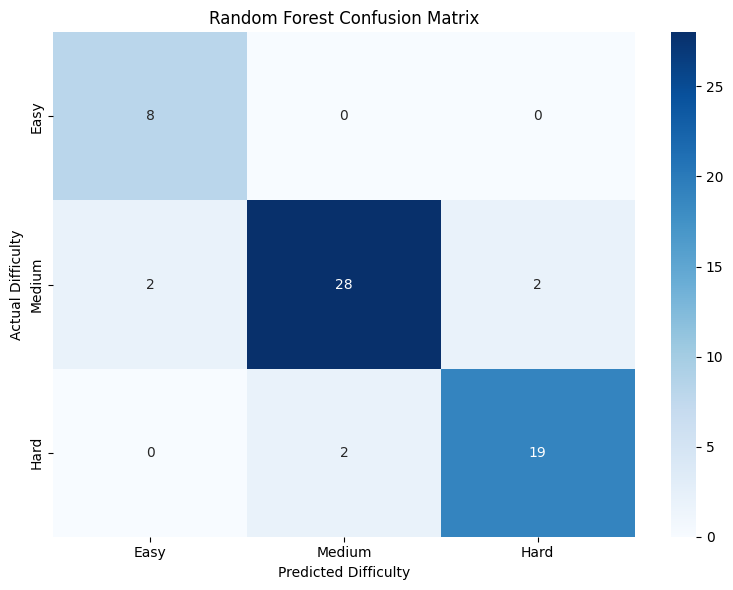

In [225]:
# Confusion matrix shows exactly which difficulty levels
# the model is confusing with each other

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Easy', 'Medium', 'Hard'],
            yticklabels=['Easy', 'Medium', 'Hard'])

plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Difficulty')
plt.xlabel('Predicted Difficulty')
plt.tight_layout()
plt.show()

In [226]:
from sklearn.model_selection import cross_val_score

# Cross validation gives more reliable accuracy estimate
# than a single train/test split
# 5-fold means we split data into 5 parts
# train on 4 parts, test on 1 part, repeat 5 times
# final score = average of all 5 runs

cv_scores = cross_val_score(
    rf_model, X, y, 
    cv=5, 
    scoring='accuracy'
)

print(f"Cross-validation scores: {cv_scores.round(4)}")
print(f"Mean accuracy:  {cv_scores.mean():.2%}")
print(f"Std deviation:  {cv_scores.std():.2%}")
print()
print(f"True model performance is approximately {cv_scores.mean():.2%} ± {cv_scores.std():.2%}")
print("Variation across folds suggests sensitivity to small dataset size")

Cross-validation scores: [0.7377 0.7869 0.9016 0.8852 0.8689]
Mean accuracy:  83.61%
Std deviation:  6.31%

True model performance is approximately 83.61% ± 6.31%
Variation across folds suggests sensitivity to small dataset size


In [227]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning using GridSearchCV
# Tries different combinations and finds the best settings
# cv=5 means 5-fold cross validation for each combination
# n_jobs=-1 uses all CPU cores to speed it up

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:  ", f"{grid_search.best_score_:.2%}")

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV score:   91.41%


In [228]:
# Train final Random Forest with best parameters found by GridSearchCV
# Final model

rf_best = grid_search.best_estimator_

y_pred_best = rf_best.predict(X_test)

print(f"Best RF Train accuracy: {rf_best.score(X_train, y_train):.2%}")
print(f"Best RF Test accuracy:  {rf_best.score(X_test, y_test):.2%}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_best,
                            target_names=['Easy', 'Medium', 'Hard']))

Best RF Train accuracy: 98.77%
Best RF Test accuracy:  90.16%

Classification Report:
              precision    recall  f1-score   support

        Easy       0.73      1.00      0.84         8
      Medium       0.96      0.84      0.90        32
        Hard       0.91      0.95      0.93        21

    accuracy                           0.90        61
   macro avg       0.87      0.93      0.89        61
weighted avg       0.91      0.90      0.90        61



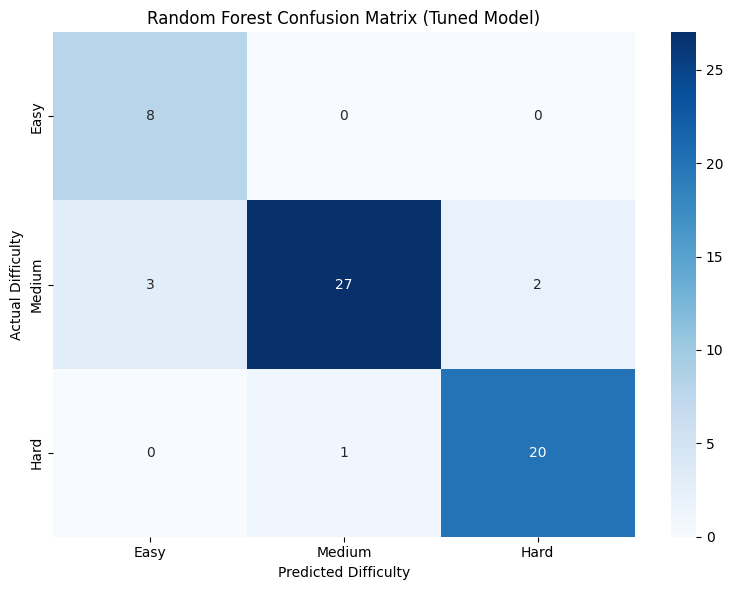

In [229]:
# Confusion matrix for the tuned model (rf_best)
# Replacing the earlier one which used the untuned model

cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Easy', 'Medium', 'Hard'],
            yticklabels=['Easy', 'Medium', 'Hard'])

plt.title('Random Forest Confusion Matrix (Tuned Model)')
plt.ylabel('Actual Difficulty')
plt.xlabel('Predicted Difficulty')
plt.tight_layout()
plt.show()

In [230]:
# Predict difficulty for ALL 305 machines
# Compare with original labels
# This shows where model agrees and disagrees with dataset labels

y_pred_all = rf_best.predict(X)

df['Predicted_Difficulty'] = y_pred_all
df['Predicted_Label'] = df['Predicted_Difficulty'].map({1:'Easy', 2:'Medium', 3:'Hard'})

# Show agreements and disagreements
df['Match'] = df['Difficulty'] == df['Predicted_Label']

print(f"Total machines: {len(df)}")
print(f"Model agrees with label:    {df['Match'].sum()} ({df['Match'].mean():.1%})")
print(f"Model disagrees with label: {(~df['Match']).sum()} ({(~df['Match']).mean():.1%})")
print()
print("Machines where model disagrees with original label:")
print(df[~df['Match']][['Machine_Name', 'Difficulty', 'Predicted_Label', 'implicit_difficulty']].to_string())

Total machines: 305
Model agrees with label:    296 (97.0%)
Model disagrees with label: 9 (3.0%)

Machines where model disagrees with original label:
        Machine_Name Difficulty Predicted_Label  implicit_difficulty
4          pWnOS 1.0     Medium            Easy             0.150519
5          pWnOS 2.0     Medium            Easy             0.150519
13        Kioptrix 5     Medium            Easy             0.136364
65   GrimTheRipper 1     Medium            Easy             0.191948
79     De-ICE S1.140       Hard          Medium             0.485909
89       FristiLeaks     Medium            Hard             0.491494
95          Fortress     Medium            Hard             0.471039
123       RootThis 1     Medium            Hard             0.471039
173  Game of Thrones       Hard          Medium             0.475909


In [231]:
import joblib

# Save the best model for use in the recommender later
joblib.dump(rf_best, '../saved_models/random_forest.pkl')
print("Best Random Forest model saved")

Best Random Forest model saved


In [232]:
# Feature importance shows which features the model found
# most useful for predicting difficulty

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 most important features:")
print(feature_importance.head(20).to_string(index=False))

Top 20 most important features:
                     feature  importance
        Estimated_Time_Hours    0.161588
          Attack_Path_Length    0.112472
         implicit_difficulty    0.094372
 skill__Directory Bruteforce    0.025335
           stage__Collection    0.023914
          obj__Reverse Shell    0.023637
            stage__Execution    0.018480
        skill__Reverse Shell    0.017631
    skill__Command Execution    0.013467
  obj__Credential Extraction    0.010401
      obj__Sudo Exploitation    0.009817
             obj__SSH Access    0.009458
skill__Credential Extraction    0.009032
       stage__Initial Access    0.008970
        skill__File Analysis    0.008693
          obj__File Analysis    0.008334
   skill__System Enumeration    0.008239
    stage__Credential Access    0.008179
         stage__Exploitation    0.008163
     obj__System Enumeration    0.008012


C:\Users\Mouri\AppData\Local\Temp\ipykernel_20136\1351286129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


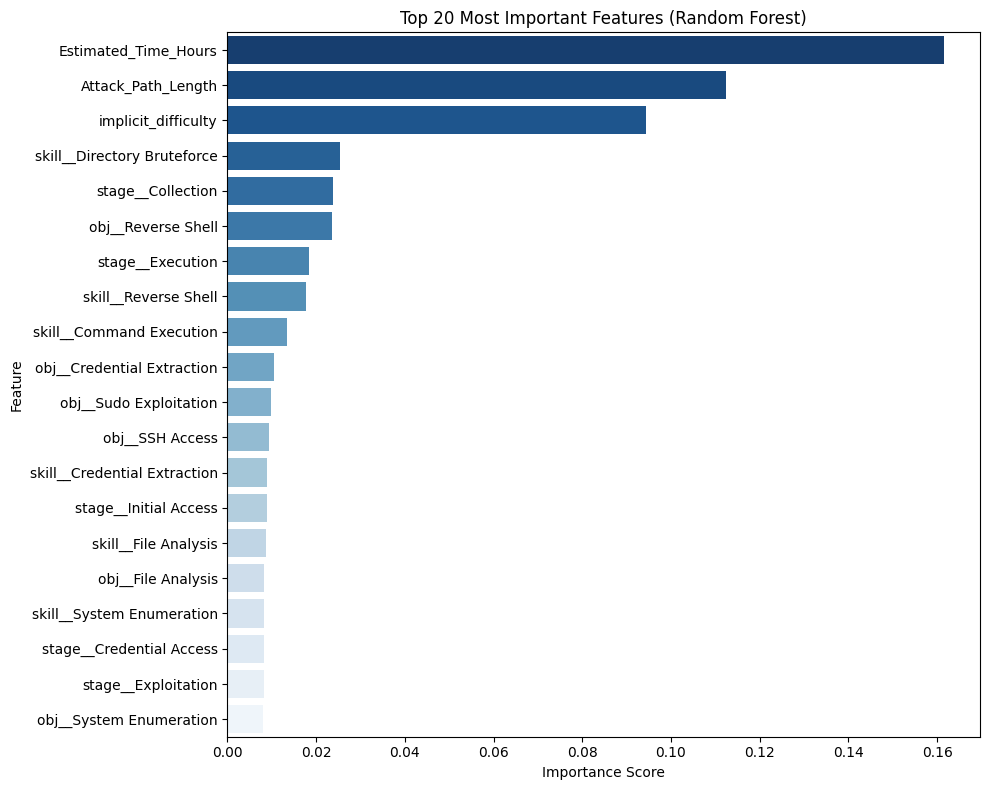

In [233]:
# Plot top 20 feature importance as a bar chart
# Visual representation is clearer than numbers alone

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(20),
    x='importance',
    y='feature',
    palette='Blues_r'
)

plt.title('Top 20 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [234]:
# Predict difficulty for ALL 305 machines
# Compare with original labels
# Shows where model agrees and disagrees

y_pred_all = rf_best.predict(X)

df['Predicted_Difficulty'] = y_pred_all
df['Predicted_Label'] = df['Predicted_Difficulty'].map({1:'Easy', 2:'Medium', 3:'Hard'})

df['Match'] = df['Difficulty'] == df['Predicted_Label']

print(f"Total machines: {len(df)}")
print(f"Model agrees with label:    {df['Match'].sum()} ({df['Match'].mean():.1%})")
print(f"Model disagrees with label: {(~df['Match']).sum()} ({(~df['Match']).mean():.1%})")
print()
print("Machines where model disagrees with original label:")
print(df[~df['Match']][['Machine_Name', 'Difficulty', 
                          'Predicted_Label', 
                          'implicit_difficulty']].to_string())

Total machines: 305
Model agrees with label:    296 (97.0%)
Model disagrees with label: 9 (3.0%)

Machines where model disagrees with original label:
        Machine_Name Difficulty Predicted_Label  implicit_difficulty
4          pWnOS 1.0     Medium            Easy             0.150519
5          pWnOS 2.0     Medium            Easy             0.150519
13        Kioptrix 5     Medium            Easy             0.136364
65   GrimTheRipper 1     Medium            Easy             0.191948
79     De-ICE S1.140       Hard          Medium             0.485909
89       FristiLeaks     Medium            Hard             0.491494
95          Fortress     Medium            Hard             0.471039
123       RootThis 1     Medium            Hard             0.471039
173  Game of Thrones       Hard          Medium             0.475909


In [235]:
# ── PHASE 4: KNN RECOMMENDATION ENGINE ──
# Loaded everything  saved in Phase 2 and Phase 3

import joblib
import numpy as np
import pandas as pd

X = joblib.load('../saved_models/feature_matrix.pkl')
y = joblib.load('../saved_models/target_y.pkl')
encoders = joblib.load('../saved_models/encoders.pkl')
scaler = joblib.load('../saved_models/scaler.pkl')
machine_info = joblib.load('../saved_models/machine_info.pkl')
rf_best = joblib.load('../saved_models/random_forest.pkl')

print(f"X shape: {X.shape}")
print(f"Machines loaded: {len(machine_info)}")
print(f"Columns in machine_info: {list(machine_info.columns)}")

X shape: (305, 771)
Machines loaded: 305
Columns in machine_info: ['Machine_ID', 'Machine_Name', 'Platform', 'OS', 'Difficulty', 'Attack_Category', 'Entry_Point', 'Estimated_Time', 'Attack_Path_Length']


In [236]:
# Converting student preferences into a feature vector
# Must be in exact same format as X (771 columns)
# So KNN can compare student input against all 305 machines

def build_student_vector(
    difficulty,           # required: 'Easy', 'Medium', 'Hard'
    attack_category,      # required: 'Web Exploitation' etc.
    os_pref,             # required: 'Linux', 'Windows', 'FreeBSD'
    vuln_type,           # required: 'SQL Injection' etc.
    learning_objectives, # required: list ['SQL Injection', 'Privilege Escalation']
    skills=None,         # optional: list ['Brute Force', 'File Upload']
    entry_point=None,    # optional: 'SQL Injection - Web Form' etc.
    platform=None        # optional: 'VulnHub', 'HackTheBox'
):
    # Start with a zero vector matching X columns
    student_vector = pd.DataFrame(
        np.zeros((1, X.shape[1])), 
        columns=X.columns
    )

    # Set difficulty numeric
    diff_map = {'Easy': 0.0, 'Medium': 0.5, 'Hard': 1.0}
    if 'implicit_difficulty' in student_vector.columns:
        student_vector['implicit_difficulty'] = diff_map.get(difficulty, 0.5)

    # Set attack category
    attack_col = f"attack_{attack_category}"
    if attack_col in student_vector.columns:
        student_vector[attack_col] = 1

    # Set OS
    os_col = f"os_{os_pref}"
    if os_col in student_vector.columns:
        student_vector[os_col] = 1

    # Set vulnerability type
    vuln_col = f"vuln__{vuln_type}"
    if vuln_col in student_vector.columns:
        student_vector[vuln_col] = 1

    # Set learning objectives
    for obj in learning_objectives:
        obj_col = f"obj__{obj}"
        if obj_col in student_vector.columns:
            student_vector[obj_col] = 1

    # Optional: skills
    if skills:
        for skill in skills:
            skill_col = f"skill__{skill}"
            if skill_col in student_vector.columns:
                student_vector[skill_col] = 1

    # Optional: entry point
    if entry_point:
        entry_col = f"entry_{entry_point}"
        if entry_col in student_vector.columns:
            student_vector[entry_col] = 1

    # Optional: platform
    if platform:
        plat_map = {'VulnHub': 0.0, 'HackTheBox': 1.0}
        if 'Platform_ID' in student_vector.columns:
            student_vector['Platform_ID'] = plat_map.get(platform, 0.0)

    return student_vector

print("Student vector builder ready")
print(f"Vector will have {X.shape[1]} features")

Student vector builder ready
Vector will have 771 features


In [237]:
# Apply feature weights based on Random Forest feature importance
# More important features get higher weights
# This makes KNN smarter — finds machines that match on features that matter most
# Instead of treating all 771 features equally

feature_weights = pd.Series(
    rf_best.feature_importances_,
    index=X.columns
)

# Apply weights to feature matrix
X_weighted = X * feature_weights

print("Feature weighting applied")
print(f"X_weighted shape: {X_weighted.shape}")
print()
print("Top 5 weighted features:")
print(feature_weights.nlargest(5))

Feature weighting applied
X_weighted shape: (305, 771)

Top 5 weighted features:
Estimated_Time_Hours           0.161588
Attack_Path_Length             0.112472
implicit_difficulty            0.094372
skill__Directory Bruteforce    0.025335
stage__Collection              0.023914
dtype: float64


In [238]:
from sklearn.neighbors import NearestNeighbors

# Train KNN on weighted feature matrix
# Using cosine similarity — works better than euclidean for high dimensional data
# n_neighbors=10 finds 10 closest machines to student preference

knn_model = NearestNeighbors(
    n_neighbors=10,
    metric='cosine',
    algorithm='brute'
)

knn_model.fit(X_weighted)

print("KNN model trained on weighted feature matrix")
print(f"Finding 10 nearest neighbors in {X_weighted.shape[1]} dimensional space")

KNN model trained on weighted feature matrix
Finding 10 nearest neighbors in 771 dimensional space


In [239]:
# Main recommendation function
# Takes student preferences and returns top N matching machines
# Ranking is done AFTER platform filtering to avoid gaps in rank numbers

def recommend_machines(
    difficulty,
    attack_category,
    os_pref,
    vuln_type,
    learning_objectives,
    skills=None,
    entry_point=None,
    platform=None,
    n_recommendations=5
):
    # Build student preference vector
    student_vector = build_student_vector(
        difficulty, attack_category, os_pref,
        vuln_type, learning_objectives,
        skills, entry_point, platform
    )

    # Apply same feature weights to student vector
    student_vector_weighted = student_vector * feature_weights

    # Find nearest machines using KNN
    distances, indices = knn_model.kneighbors(student_vector_weighted)

    # Build results without rank first
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        machine = machine_info.iloc[idx]
        similarity = 1 - dist

        # Filter by platform if specified
        if platform and machine['Platform'] != platform:
            continue

        results.append({
            'Machine_Name': machine['Machine_Name'],
            'Platform': machine['Platform'],
            'OS': machine['OS'],
            'Difficulty': machine['Difficulty'],
            'Attack_Category': machine['Attack_Category'],
            'Entry_Point': machine['Entry_Point'],
            'Estimated_Time': machine['Estimated_Time'],
            'Similarity_Score': round(similarity * 100, 2)
        })

    # Rank AFTER filtering so ranks are always 1, 2, 3, 4, 5
    results_df = pd.DataFrame(results).head(n_recommendations)
    results_df.insert(0, 'Rank', range(1, len(results_df) + 1))

    return results_df

print("Recommendation function ready")

Recommendation function ready


In [240]:
# Test 1 — Beginner student
# Wants Easy, Web Exploitation, Linux, SQL Injection
# Learning objective: SQL Injection and Privilege Escalation

results = recommend_machines(
    difficulty='Easy',
    attack_category='Web Exploitation',
    os_pref='Linux',
    vuln_type='SQL Injection',
    learning_objectives=['SQL Injection', 'Privilege Escalation'],
    n_recommendations=5
)

print("Recommended machines for beginner student:")
print(results.to_string(index=False))

Recommended machines for beginner student:
 Rank       Machine_Name Platform    OS Difficulty  Attack_Category                           Entry_Point Estimated_Time  Similarity_Score
    1 LAMPSecurity CTF 4  VulnHub Linux       Easy Web Exploitation SQL Injection (login/input parameter)        <1 hour             17.88
    2         Seattle VM  VulnHub Linux       Easy Web Exploitation                Web Application (HTTP)    1-1.5 hours             13.44
    3 Kioptrix Level 1.1  VulnHub Linux       Easy Web Exploitation       SQL Injection (web application)      1-2 hours              9.77
    4            Freshly  VulnHub Linux       Easy Web Exploitation         SQL Injection (web parameter)      1-2 hours              9.23
    5 Kioptrix Level 1.2  VulnHub Linux       Easy Web Exploitation          SQL Injection (login bypass)      1-2 hours              9.18


In [241]:
# More ML-driven recommendation
# Step 1: KNN finds candidate machines based on feature similarity
# Step 2: Random Forest predicts difficulty for each candidate
# Step 3: Filter candidates where RF predicted difficulty matches student preference
# Step 4: Rank by similarity score

def recommend_machines_ml(
    difficulty,
    attack_category,
    os_pref,
    vuln_type,
    learning_objectives,
    skills=None,
    entry_point=None,
    platform=None,
    n_recommendations=5
):
    # Build and weight student vector
    student_vector = build_student_vector(
        difficulty, attack_category, os_pref,
        vuln_type, learning_objectives,
        skills, entry_point, platform
    )
    student_vector_weighted = student_vector * feature_weights

    # KNN finds 20 nearest candidates
    distances, indices = knn_model.kneighbors(
        student_vector_weighted, n_neighbors=20
    )

    # Build candidate list
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        machine = machine_info.iloc[idx]
        similarity = 1 - dist

        # Platform filter if specified
        if platform and machine['Platform'] != platform:
            continue

        # Get machine feature vector
        machine_features = X_weighted.iloc[idx:idx+1]

        # Random Forest predicts difficulty for this machine
        rf_predicted_difficulty = rf_best.predict(X.iloc[idx:idx+1])[0]
        rf_predicted_label = {1:'Easy', 2:'Medium', 3:'Hard'}[rf_predicted_difficulty]

        results.append({
            'Machine_Name': machine['Machine_Name'],
            'Platform': machine['Platform'],
            'OS': machine['OS'],
            'Difficulty': machine['Difficulty'],
            'RF_Predicted_Difficulty': rf_predicted_label,
            'Attack_Category': machine['Attack_Category'],
            'Entry_Point': machine['Entry_Point'],
            'Estimated_Time': machine['Estimated_Time'],
            'Similarity_Score': round(similarity * 100, 2)
        })

    results_df = pd.DataFrame(results)

    # Filter where RF prediction matches student difficulty preference
    # This is the ML layer — not just keyword matching
    difficulty_match = results_df[
        results_df['RF_Predicted_Difficulty'] == difficulty
    ]

    # If enough matches found use them, otherwise use all results
    if len(difficulty_match) >= n_recommendations:
        final_results = difficulty_match.head(n_recommendations)
    else:
        final_results = results_df.head(n_recommendations)

    # Rank after filtering
    final_results = final_results.copy()
    final_results.insert(0, 'Rank', range(1, len(final_results) + 1))

    return final_results

print("ML-enhanced recommendation function ready")

ML-enhanced recommendation function ready


In [242]:
# Test ML-enhanced recommender with same beginner profile
# Compare results with basic recommender above

results_ml = recommend_machines_ml(
    difficulty='Easy',
    attack_category='Web Exploitation',
    os_pref='Linux',
    vuln_type='SQL Injection',
    learning_objectives=['SQL Injection', 'Privilege Escalation'],
    n_recommendations=5
)

print("ML-enhanced recommendations for beginner student:")
print(results_ml.to_string(index=False))

ML-enhanced recommendations for beginner student:
 Rank       Machine_Name Platform    OS Difficulty RF_Predicted_Difficulty  Attack_Category                           Entry_Point Estimated_Time  Similarity_Score
    1 LAMPSecurity CTF 4  VulnHub Linux       Easy                    Easy Web Exploitation SQL Injection (login/input parameter)        <1 hour             17.88
    2         Seattle VM  VulnHub Linux       Easy                    Easy Web Exploitation                Web Application (HTTP)    1-1.5 hours             13.44
    3 Kioptrix Level 1.1  VulnHub Linux       Easy                    Easy Web Exploitation       SQL Injection (web application)      1-2 hours              9.77
    4            Freshly  VulnHub Linux       Easy                    Easy Web Exploitation         SQL Injection (web parameter)      1-2 hours              9.23
    5 Kioptrix Level 1.2  VulnHub Linux       Easy                    Easy Web Exploitation          SQL Injection (login bypass)      

In [243]:
# Test 2 — Advanced student
# Wants Hard, Network Exploitation, Linux, wants to learn pivoting and binary

results_advanced = recommend_machines_ml(
    difficulty='Hard',
    attack_category='Network Exploitation',
    os_pref='Linux',
    vuln_type='SMB Enumeration',
    learning_objectives=['Pivoting', 'Network Pivoting', 'Privilege Escalation'],
    skills=['Pivoting', 'Port Forwarding', 'SMB Enumeration'],
    n_recommendations=5
)

print("Recommendations for advanced student:")
print(results_advanced.to_string(index=False))

Recommendations for advanced student:
 Rank Machine_Name Platform    OS Difficulty RF_Predicted_Difficulty      Attack_Category                                                   Entry_Point Estimated_Time  Similarity_Score
    1   W34kn3ss 1  VulnHub Linux       Hard                    Hard     Web Exploitation         Web + System + Crypto Exploitation (HTTP, HTTPS, SSH)      3-4 hours             50.80
    2      Tr0ll 2  VulnHub Linux       Hard                    Hard  Binary Exploitation           Web + System + Binary Exploitation (HTTP, FTP, SSH)    3.5-4 hours             50.32
    3   Symfonos 2  VulnHub Linux       Hard                    Hard Network Exploitation     Web + Network + System Exploitation (HTTP, FTP, SMB, SSH)      3-4 hours             48.40
    4  FristiLeaks  VulnHub Linux     Medium                    Hard     Web Exploitation Web + System Exploitation (HTTP → Local Privilege Escalation)    2.5-3 hours             47.56
    5  Star Wars 1  VulnHub Linux    

In [244]:
# Test 3 — Intermediate student, network focused
# Wants Medium difficulty, Network Exploitation, Linux

results_network = recommend_machines_ml(
    difficulty='Medium',
    attack_category='Network Exploitation',
    os_pref='Linux',
    vuln_type='SMB Enumeration',
    learning_objectives=['SMB Enumeration', 'Credential Extraction', 
                         'Privilege Escalation'],
    n_recommendations=5
)

print("Recommendations for network-focused student:")
print(results_network.to_string(index=False))

Recommendations for network-focused student:
 Rank       Machine_Name Platform    OS Difficulty RF_Predicted_Difficulty            Attack_Category                                                    Entry_Point Estimated_Time  Similarity_Score
    1         Symfonos 1  VulnHub Linux     Medium                  Medium       Network Exploitation           Web + Network + System Exploitation (HTTP, SMB, SSH)      2-3 hours             54.09
    2            Tr0ll 3  VulnHub Linux     Medium                  Medium           Web Exploitation                          Web + System Exploitation (HTTP, SSH)      2-3 hours             50.60
    3            Covfefe  VulnHub Linux     Medium                  Medium        Binary Exploitation                                       Web + System (HTTP, SSH)      1-2 hours             50.52
    4 Padding Oracle Lab  VulnHub Linux     Medium                  Medium Cryptographic Exploitation                               Web + Crypto Exploitation (HTTP

In [245]:
# Test 4 — Beginner with only required fields filled
# This tests that optional fields being empty does not break anything
# And system still returns sensible results

results_minimal = recommend_machines_ml(
    difficulty='Easy',
    attack_category='Web Exploitation',
    os_pref='Linux',
    vuln_type='File Upload',
    learning_objectives=['File Upload', 'Privilege Escalation'],
    n_recommendations=5
)

print("Recommendations with only required fields (no optional inputs):")
print(results_minimal.to_string(index=False))

Recommendations with only required fields (no optional inputs):
 Rank         Machine_Name Platform    OS Difficulty RF_Predicted_Difficulty  Attack_Category                                   Entry_Point Estimated_Time  Similarity_Score
    1   LAMPSecurity CTF 4  VulnHub Linux       Easy                    Easy Web Exploitation         SQL Injection (login/input parameter)        <1 hour             12.22
    2           Billu: B)x  VulnHub Linux       Easy                    Easy Web Exploitation                    Local File Inclusion (LFI)         1 hour             11.34
    3 Pentester Lab S2-052  VulnHub Linux       Easy                    Easy Web Exploitation                        Web Application (HTTP)         1 hour              8.99
    4   RickdiculouslyEasy  VulnHub Linux       Easy                    Easy Web Exploitation      Information Disclosure (web enumeration)      1-2 hours              8.40
    5               Sedena  VulnHub Linux       Easy                   

In [246]:
# Save KNN model for use in Flask API later
joblib.dump(knn_model, '../saved_models/knn_model.pkl')
joblib.dump(feature_weights, '../saved_models/feature_weights.pkl')

print("KNN model and feature weights saved")
print(os.listdir('../saved_models'))

KNN model and feature weights saved
['ai_recommender', 'encoders.pkl', 'feature_matrix.pkl', 'feature_weights.pkl', 'knn_model.pkl', 'machine_info.pkl', 'random_forest.pkl', 'roc_curve.png', 'scaler.pkl', 'target_y.pkl']


Total features: 771
Features with importance > 0:      642
Features with importance > 0.001:  110
Features with importance > 0.002:  74
Features with importance > 0.005:  36



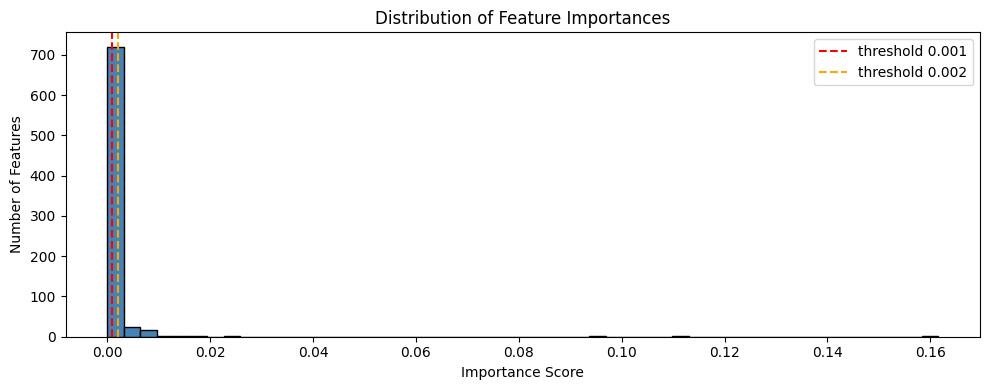

In [247]:
import matplotlib.pyplot as plt

# Check distribution of feature importances
# This tells us where to set the threshold

print(f"Total features: {len(feature_weights)}")
print(f"Features with importance > 0:      {(feature_weights > 0).sum()}")
print(f"Features with importance > 0.001:  {(feature_weights > 0.001).sum()}")
print(f"Features with importance > 0.002:  {(feature_weights > 0.002).sum()}")
print(f"Features with importance > 0.005:  {(feature_weights > 0.005).sum()}")
print()

# Plot distribution
plt.figure(figsize=(10, 4))
plt.hist(feature_weights, bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Number of Features')
plt.axvline(x=0.001, color='red', linestyle='--', label='threshold 0.001')
plt.axvline(x=0.002, color='orange', linestyle='--', label='threshold 0.002')
plt.legend()
plt.tight_layout()
plt.show()

In [248]:
# Apply feature weights based on Random Forest feature importance
# More important features get higher weights
# This makes KNN smarter — finds machines that match on features that matter most
# Instead of treating all 771 features equally

feature_weights = pd.Series(
    rf_best.feature_importances_,
    index=X.columns
)

# Apply weights to feature matrix
X_weighted = X * feature_weights

print("Feature weighting applied")
print(f"X_weighted shape: {X_weighted.shape}")
print()
print("Top 5 weighted features:")
print(feature_weights.nlargest(5))

Feature weighting applied
X_weighted shape: (305, 771)

Top 5 weighted features:
Estimated_Time_Hours           0.161588
Attack_Path_Length             0.112472
implicit_difficulty            0.094372
skill__Directory Bruteforce    0.025335
stage__Collection              0.023914
dtype: float64


In [249]:
# Find the right threshold to keep 150-250 features
# We want enough features to be meaningful but not too many to cause sparsity

for threshold in [0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0008, 0.001]:
    count = (feature_weights > threshold).sum()
    print(f"Threshold {threshold}: {count} features kept")

Threshold 0.0001: 493 features kept
Threshold 0.0002: 376 features kept
Threshold 0.0003: 280 features kept
Threshold 0.0004: 231 features kept
Threshold 0.0005: 194 features kept
Threshold 0.0008: 134 features kept
Threshold 0.001: 110 features kept


In [250]:
# Keep features with importance above 0.0004
# This reduces from 771 to 231 features
# Removes noise while keeping all meaningful features

threshold = 0.0004
selected_features = feature_weights[feature_weights > threshold].index.tolist()

print(f"Features kept:    {len(selected_features)}")
print(f"Features removed: {771 - len(selected_features)}")
print()

# Apply feature selection to X
X_selected = X[selected_features]
X_weighted_selected = X_selected * feature_weights[selected_features]

print(f"X_selected shape:         {X_selected.shape}")
print(f"X_weighted_selected shape: {X_weighted_selected.shape}")

Features kept:    231
Features removed: 540

X_selected shape:         (305, 231)
X_weighted_selected shape: (305, 231)


In [251]:
# Keep features with importance above 0.0004
# This reduces from 771 to 231 features
# Removes noise while keeping all meaningful features

threshold = 0.0004
selected_features = feature_weights[feature_weights > threshold].index.tolist()

print(f"Features kept:    {len(selected_features)}")
print(f"Features removed: {771 - len(selected_features)}")
print()

# Apply feature selection to X
X_selected = X[selected_features]
X_weighted_selected = X_selected * feature_weights[selected_features]

print(f"X_selected shape:         {X_selected.shape}")
print(f"X_weighted_selected shape: {X_weighted_selected.shape}")

Features kept:    231
Features removed: 540

X_selected shape:         (305, 231)
X_weighted_selected shape: (305, 231)


In [252]:
# Retrain KNN on reduced feature set (231 features)
# This should give higher similarity scores and better recommendations

knn_model_selected = NearestNeighbors(
    n_neighbors=10,
    metric='cosine',
    algorithm='brute'
)

knn_model_selected.fit(X_weighted_selected)

print("KNN retrained on 231 selected features")
print(f"Finding 10 nearest neighbors in {X_weighted_selected.shape[1]} dimensional space")

KNN retrained on 231 selected features
Finding 10 nearest neighbors in 231 dimensional space


In [253]:
# Updated ML recommendation function using 231 selected features
# Should give higher similarity scores than before

def recommend_machines_v2(
    difficulty,
    attack_category,
    os_pref,
    vuln_type,
    learning_objectives,
    skills=None,
    entry_point=None,
    platform=None,
    n_recommendations=5
):
    # Build student preference vector using full 771 features first
    student_vector = build_student_vector(
        difficulty, attack_category, os_pref,
        vuln_type, learning_objectives,
        skills, entry_point, platform
    )

    # Select only the 231 important features
    student_vector_selected = student_vector[selected_features]

    # Apply feature weights
    student_vector_weighted = student_vector_selected * feature_weights[selected_features]

    # Find nearest machines
    distances, indices = knn_model_selected.kneighbors(student_vector_weighted)

    # Build results
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        machine = machine_info.iloc[idx]
        similarity = 1 - dist

        # Filter by platform if specified
        if platform and machine['Platform'] != platform:
            continue

        # RF predicts difficulty for this machine
        rf_predicted_difficulty = rf_best.predict(X.iloc[idx:idx+1])[0]
        rf_predicted_label = {1:'Easy', 2:'Medium', 3:'Hard'}[rf_predicted_difficulty]

        results.append({
            'Machine_Name': machine['Machine_Name'],
            'Platform': machine['Platform'],
            'OS': machine['OS'],
            'Difficulty': machine['Difficulty'],
            'RF_Predicted_Difficulty': rf_predicted_label,
            'Attack_Category': machine['Attack_Category'],
            'Entry_Point': machine['Entry_Point'],
            'Estimated_Time': machine['Estimated_Time'],
            'Similarity_Score': round(similarity * 100, 2)
        })

    # Rank after filtering
    results_df = pd.DataFrame(results).head(n_recommendations)
    results_df.insert(0, 'Rank', range(1, len(results_df) + 1))

    return results_df

print("Updated recommendation function v2 ready")

Updated recommendation function v2 ready


In [254]:
# Test v2 with beginner profile
# Compare similarity scores with previous version
# Before: top similarity was 17.88
# Expecting higher scores now with 231 features

results_v2_beginner = recommend_machines_v2(
    difficulty='Easy',
    attack_category='Web Exploitation',
    os_pref='Linux',
    vuln_type='SQL Injection',
    learning_objectives=['SQL Injection', 'Privilege Escalation'],
    n_recommendations=5
)

print("V2 Recommendations for beginner student:")
print(results_v2_beginner.to_string(index=False))
print()
print(f"Previous top similarity: 17.88")
print(f"New top similarity:      {results_v2_beginner['Similarity_Score'].max()}")

V2 Recommendations for beginner student:
 Rank       Machine_Name Platform    OS Difficulty RF_Predicted_Difficulty  Attack_Category                           Entry_Point Estimated_Time  Similarity_Score
    1 LAMPSecurity CTF 4  VulnHub Linux       Easy                    Easy Web Exploitation SQL Injection (login/input parameter)        <1 hour             17.88
    2         Seattle VM  VulnHub Linux       Easy                    Easy Web Exploitation                Web Application (HTTP)    1-1.5 hours             13.44
    3 Kioptrix Level 1.1  VulnHub Linux       Easy                    Easy Web Exploitation       SQL Injection (web application)      1-2 hours              9.76
    4            Freshly  VulnHub Linux       Easy                    Easy Web Exploitation         SQL Injection (web parameter)      1-2 hours              9.22
    5 Kioptrix Level 1.2  VulnHub Linux       Easy                    Easy Web Exploitation          SQL Injection (login bypass)      1-2 hours

In [ ]:
# ── LIVE DEMO — Student Preference Input ─────────────────────────────────────
# 

# ── REQUIRED INPUTS ──────────────────────────────────────────────────────────
difficulty        = 'Easy'           # 'Easy', 'Medium', 'Hard'
attack_category   = 'Web Exploitation'  # 'Web Exploitation', 'Network Exploitation',
                                        # 'Binary Exploitation', 'Cryptographic Exploitation',
                                        # 'Mixed (Web + Network)', 'Credential-Based Exploitation'
os_pref           = 'Linux'          # 'Linux', 'Windows', 'FreeBSD'
vuln_type         = 'SQL Injection'  # e.g. 'SQL Injection', 'File Upload', 'Local File Inclusion (LFI)'
learning_objectives = ['SQL Injection', 'Privilege Escalation']  # what student wants to learn

# ── OPTIONAL INPUTS (leave as None if not needed) 
skills        = None    # e.g. ['Brute Force', 'File Upload'] or None
entry_point   = None    # e.g. 'SQL Injection - Web Form' or None
platform      = None    # 'VulnHub', 'HackTheBox' or None (None = all platforms)

# ── NUMBER OF RECOMMENDATIONS ────────────────────────────
n_recommendations = 5

# ── RUN RECOMMENDER ───────────────────────────────────────────────────────────
print("=" * 60)
print("STUDENT PREFERENCE SUMMARY")
print("=" * 60)
print(f"Difficulty:          {difficulty}")
print(f"Attack Category:     {attack_category}")
print(f"OS:                  {os_pref}")
print(f"Vulnerability Type:  {vuln_type}")
print(f"Learning Objectives: {learning_objectives}")
print(f"Skills (optional):   {skills}")
print(f"Entry Point:         {entry_point}")
print(f"Platform:            {platform if platform else 'All Platforms'}")
print("=" * 60)
print()

results = recommend_machines_ml(
    difficulty=difficulty,
    attack_category=attack_category,
    os_pref=os_pref,
    vuln_type=vuln_type,
    learning_objectives=learning_objectives,
    skills=skills,
    entry_point=entry_point,
    platform=platform,
    n_recommendations=n_recommendations
)

print(f"TOP {n_recommendations} RECOMMENDED MACHINES")
print("=" * 60)
print(results.to_string(index=False))

STUDENT PREFERENCE SUMMARY
Difficulty:          Easy
Attack Category:     Web Exploitation
OS:                  Linux
Vulnerability Type:  SQL Injection
Learning Objectives: ['SQL Injection', 'Privilege Escalation']
Skills (optional):   None
Entry Point:         None
Platform:            All Platforms

TOP 5 RECOMMENDED MACHINES
 Rank       Machine_Name Platform    OS Difficulty RF_Predicted_Difficulty  Attack_Category                           Entry_Point Estimated_Time  Similarity_Score
    1 LAMPSecurity CTF 4  VulnHub Linux       Easy                    Easy Web Exploitation SQL Injection (login/input parameter)        <1 hour             17.88
    2         Seattle VM  VulnHub Linux       Easy                    Easy Web Exploitation                Web Application (HTTP)    1-1.5 hours             13.44
    3 Kioptrix Level 1.1  VulnHub Linux       Easy                    Easy Web Exploitation       SQL Injection (web application)      1-2 hours              9.77
    4            

In [256]:
import ipywidgets as widgets
print(widgets.__version__)
w = widgets.Dropdown(options=['A','B','C'])
display(w)

8.1.8


Dropdown(options=('A', 'B', 'C'), value='A')

In [257]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── INTERACTIVE DEMO ──────────────────────────────────────────────────────────


difficulty_widget = widgets.Dropdown(
    options=['Easy', 'Medium', 'Hard'],
    value='Easy',
    description='Difficulty:',
    style={'description_width': 'initial'}
)

attack_widget = widgets.Dropdown(
    options=['Web Exploitation', 'Network Exploitation', 
             'Binary Exploitation', 'Cryptographic Exploitation',
             'Mixed (Web + Network)', 'Credential-Based Exploitation'],
    value='Web Exploitation',
    description='Attack Category:',
    style={'description_width': 'initial'}
)

os_widget = widgets.Dropdown(
    options=['Linux', 'Windows', 'FreeBSD'],
    value='Linux',
    description='OS:',
    style={'description_width': 'initial'}
)

vuln_widget = widgets.Dropdown(
    options=['SQL Injection', 'File Upload', 'Local File Inclusion (LFI)',
             'Remote Code Execution', 'Command Injection', 
             'Blind SQL Injection', 'Insecure Deserialization',
             'WordPress Exploitation', 'Buffer Overflow',
             'SMB Enumeration', 'Weak Credentials'],
    value='SQL Injection',
    description='Vulnerability Type:',
    style={'description_width': 'initial'}
)

objectives_widget = widgets.SelectMultiple(
    options=['SQL Injection', 'File Upload', 'Privilege Escalation',
             'Credential Extraction', 'Reverse Shell', 'Web Enumeration',
             'SSH Access', 'Brute Force', 'SMB Enumeration',
             'Network Pivoting', 'Buffer Overflow', 'Steganography',
             'Hash Cracking', 'Directory Bruteforce', 'Port Scanning'],
    value=['SQL Injection', 'Privilege Escalation'],
    description='Learning Objectives (hold Ctrl to select multiple):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px', height='150px')
)

platform_widget = widgets.Dropdown(
    options=['All Platforms', 'VulnHub', 'HackTheBox'],
    value='All Platforms',
    description='Platform:',
    style={'description_width': 'initial'}
)

n_widget = widgets.IntSlider(
    value=5,
    min=1,
    max=10,
    step=1,
    description='No. of Recommendations:',
    style={'description_width': 'initial'}
)

button = widgets.Button(
    description='Get Recommendations',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()
        platform = None if platform_widget.value == 'All Platforms' else platform_widget.value
        
        print("=" * 60)
        print("STUDENT PREFERENCE SUMMARY")
        print("=" * 60)
        print(f"Difficulty:          {difficulty_widget.value}")
        print(f"Attack Category:     {attack_widget.value}")
        print(f"OS:                  {os_widget.value}")
        print(f"Vulnerability Type:  {vuln_widget.value}")
        print(f"Learning Objectives: {list(objectives_widget.value)}")
        print(f"Platform:            {platform_widget.value}")
        print("=" * 60)
        print()

        results = recommend_machines_ml(
            difficulty=difficulty_widget.value,
            attack_category=attack_widget.value,
            os_pref=os_widget.value,
            vuln_type=vuln_widget.value,
            learning_objectives=list(objectives_widget.value),
            platform=platform,
            n_recommendations=n_widget.value
        )

        print(f"TOP {n_widget.value} RECOMMENDED MACHINES")
        print("=" * 60)
        
        # Display each machine as a separate block
        for _, row in results.iterrows():
            print(f"Rank {int(row['Rank'])}: {row['Machine_Name']}")
            print(f"  Platform:             {row['Platform']}")
            print(f"  OS:                   {row['OS']}")
            print(f"  Difficulty (Label):   {row['Difficulty']}")
            print(f"  Difficulty (RF Pred): {row['RF_Predicted_Difficulty']}")
            print(f"  Attack Category:      {row['Attack_Category']}")
            print(f"  Entry Point:          {row['Entry_Point']}")
            print(f"  Estimated Time:       {row['Estimated_Time']}")
            print(f"  Similarity Score:     {row['Similarity_Score']}%")
            print("-" * 40)

button.on_click(on_button_click)

# Display all widgets
display(widgets.VBox([
    widgets.Label('── Student Preference Input ──'),
    difficulty_widget,
    attack_widget,
    os_widget,
    vuln_widget,
    objectives_widget,
    platform_widget,
    n_widget,
    button,
    output
]))

In [258]:
# Fixing and  Hard filter on attack category
# Previously the system could return Web Exploitation machines
# even when student selected Binary Exploitation
# Now we strictly filter to only return machines matching selected category

def get_machines_by_category(attack_category, difficulty=None):
    # Find all machines matching the selected attack category
    mask = machine_info['Attack_Category'] == attack_category
    
    #  filter by difficulty if specified
    if difficulty:
        mask = mask & (machine_info['Difficulty'] == difficulty)
    
    matching_indices = machine_info[mask].index.tolist()
    
    print(f"Attack Category '{attack_category}' + Difficulty '{difficulty}':")
    print(f"  Matching machines found: {len(matching_indices)}")
    
    return matching_indices

# Test — check how many machines exist for each category and difficulty combination
print("Available machines per category and difficulty:")
print("=" * 55)
for cat in df['Attack_Category'].unique():
    for diff in ['Easy', 'Medium', 'Hard']:
        indices = get_machines_by_category(cat, diff)

Available machines per category and difficulty:
Attack Category 'Web Exploitation' + Difficulty 'Easy':
  Matching machines found: 34
Attack Category 'Web Exploitation' + Difficulty 'Medium':
  Matching machines found: 143
Attack Category 'Web Exploitation' + Difficulty 'Hard':
  Matching machines found: 87
Attack Category 'Network Exploitation' + Difficulty 'Easy':
  Matching machines found: 4
Attack Category 'Network Exploitation' + Difficulty 'Medium':
  Matching machines found: 11
Attack Category 'Network Exploitation' + Difficulty 'Hard':
  Matching machines found: 13
Attack Category 'Mixed (Web + Network)' + Difficulty 'Easy':
  Matching machines found: 2
Attack Category 'Mixed (Web + Network)' + Difficulty 'Medium':
  Matching machines found: 2
Attack Category 'Mixed (Web + Network)' + Difficulty 'Hard':
  Matching machines found: 1
Attack Category 'Binary Exploitation' + Difficulty 'Easy':
  Matching machines found: 0
Attack Category 'Binary Exploitation' + Difficulty 'Medium':

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

#  Masked cosine similarity
# Instead of comparing all 771 features, I only compare on features
# that the student actually specified (non-zero values)
# This gives more meaningful similarity scores


def masked_cosine_similarity(student_vector, machine_matrix):
    # Find which features the student actually specified
    student_array = student_vector.values[0]
    active_mask = student_array != 0
    
    print(f"  Student specified {active_mask.sum()} active features out of {len(active_mask)}")
    
    # If student specified nothing use all features
    if active_mask.sum() == 0:
        active_mask = np.ones(len(active_mask), dtype=bool)
    
    # Compare only on active features
    student_active = student_array[active_mask].reshape(1, -1)
    machines_active = machine_matrix.values[:, active_mask]
    
    # Compute cosine similarity on active features only
    similarities = cos_sim(student_active, machines_active)[0]
    
    return similarities

print("Masked cosine similarity function ready")

Masked cosine similarity function ready


In [ ]:
# Fix 3: Fallback mechanism
# If not enough machines match the selected category + difficulty combination


def get_available_machines_with_fallback(attack_category, difficulty, min_machines=5):
    
    # First try exact match — category + difficulty
    exact_indices = get_machines_by_category(attack_category, difficulty)
    
    if len(exact_indices) >= min_machines:
        return exact_indices, "exact"
    
    # Not enough — relax difficulty filter, keep category
    category_only_indices = get_machines_by_category(attack_category, difficulty=None)
    
    if len(category_only_indices) >= min_machines:
        return category_only_indices, "category_only"
    
    # Still not enough — use all machines with selected difficulty
    diff_mask = machine_info['Difficulty'] == difficulty
    diff_indices = machine_info[diff_mask].index.tolist()
    
    if len(diff_indices) >= min_machines:
        return diff_indices, "difficulty_only"
    
    # Last resort — use all machines
    return machine_info.index.tolist(), "all"

# Test fallback with rare combinations
print("Testing fallback mechanism:")
print("=" * 55)

test_cases = [
    ('Binary Exploitation', 'Easy'),
    ('Credential-Based Exploitation', 'Easy'),
    ('Cryptographic Exploitation', 'Medium'),
    ('Web Exploitation', 'Easy'),
    ('Network Exploitation', 'Medium'),
]

for cat, diff in test_cases:
    indices, mode = get_available_machines_with_fallback(cat, diff)
    print(f"\n{cat} + {diff}:")
    print(f"  Mode used: {mode}")
    print(f"  Machines available: {len(indices)}")

Testing fallback mechanism:
Attack Category 'Binary Exploitation' + Difficulty 'Easy':
  Matching machines found: 0
Attack Category 'Binary Exploitation' + Difficulty 'None':
  Matching machines found: 3

Binary Exploitation + Easy:
  Mode used: difficulty_only
  Machines available: 40
Attack Category 'Credential-Based Exploitation' + Difficulty 'Easy':
  Matching machines found: 0
Attack Category 'Credential-Based Exploitation' + Difficulty 'None':
  Matching machines found: 3

Credential-Based Exploitation + Easy:
  Mode used: difficulty_only
  Machines available: 40
Attack Category 'Cryptographic Exploitation' + Difficulty 'Medium':
  Matching machines found: 1
Attack Category 'Cryptographic Exploitation' + Difficulty 'None':
  Matching machines found: 2

Cryptographic Exploitation + Medium:
  Mode used: difficulty_only
  Machines available: 159
Attack Category 'Web Exploitation' + Difficulty 'Easy':
  Matching machines found: 34

Web Exploitation + Easy:
  Mode used: exact
  Machin

In [261]:
# message to student
# Informing the student when their exact preference could not be fully matched

def get_fallback_message(mode, attack_category, difficulty):
    if mode == "exact":
        return None  # No message needed — exact match found
    
    elif mode == "category_only":
        return (
            f"Note: Limited machines found for '{attack_category}' + '{difficulty}'. "
            f"Showing best matches from all '{attack_category}' machines regardless of difficulty."
        )
    
    elif mode == "difficulty_only":
        return (
            f"Note: Very few '{attack_category}' machines exist in our dataset. "
            f"Showing best '{difficulty}' machines from all categories instead. "
            f"Consider trying 'Web Exploitation' or 'Network Exploitation' for more options."
        )
    
    elif mode == "all":
        return (
            f"Note: Limited machines found for your combination. "
            f"Showing best overall matches. "
            f"Consider broadening your preferences for better results."
        )

print("Fallback message function ready")

Fallback message function ready


In [262]:
# Final recommendation function combining all 4 fixes:
# Fix 1: Hard filter on attack category
# Fix 2: Masked cosine similarity for better scores
# Fix 3: Fallback mechanism for rare combinations


def recommend_final(
    difficulty,
    attack_category,
    os_pref,
    vuln_type,
    learning_objectives,
    skills=None,
    entry_point=None,
    platform=None,
    n_recommendations=5
):
    # Step 1: Build student preference vector
    student_vector = build_student_vector(
        difficulty, attack_category, os_pref,
        vuln_type, learning_objectives,
        skills, entry_point, platform
    )

    # Step 2: Get available machines with fallback
    available_indices, mode = get_available_machines_with_fallback(
        attack_category, difficulty
    )

    # Step 3: Get fallback message if needed
    fallback_msg = get_fallback_message(mode, attack_category, difficulty)

    # Step 4: Apply platform filter if specified
    if platform:
        available_indices = [
            i for i in available_indices 
            if machine_info.iloc[i]['Platform'] == platform
        ]

    # Step 5: Get feature matrix for available machines only
    X_available = X.iloc[available_indices]

    # Step 6: Apply feature weights
    student_vector_weighted = student_vector * feature_weights
    X_available_weighted = X_available * feature_weights

    # Step 7: Masked cosine similarity — only on features student specified
    similarities = masked_cosine_similarity(
        student_vector_weighted,
        X_available_weighted
    )

    # Step 8: Get top indices by similarity
    top_local_indices = similarities.argsort()[::-1][:20]
    top_global_indices = [available_indices[i] for i in top_local_indices]

    # Step 9: Build results with RF validation
    results = []
    for local_idx, global_idx in zip(top_local_indices, top_global_indices):
        machine = machine_info.iloc[global_idx]
        similarity = similarities[local_idx]

        # RF independently predicts difficulty for this machine
        rf_predicted_difficulty = rf_best.predict(X.iloc[global_idx:global_idx+1])[0]
        rf_predicted_label = {1:'Easy', 2:'Medium', 3:'Hard'}[rf_predicted_difficulty]

        results.append({
            'Machine_Name': machine['Machine_Name'],
            'Platform': machine['Platform'],
            'OS': machine['OS'],
            'Difficulty': machine['Difficulty'],
            'RF_Predicted_Difficulty': rf_predicted_label,
            'Attack_Category': machine['Attack_Category'],
            'Entry_Point': machine['Entry_Point'],
            'Estimated_Time': machine['Estimated_Time'],
            'Similarity_Score': round(similarity * 100, 2)
        })

    # Step 10: Rank after all filtering
    results_df = pd.DataFrame(results).head(n_recommendations)
    results_df.insert(0, 'Rank', range(1, len(results_df) + 1))

    return results_df, fallback_msg

print("Final recommendation function ready")

Final recommendation function ready


In [263]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Interactive demo using the final improved recommendation function


difficulty_widget = widgets.Dropdown(
    options=['Easy', 'Medium', 'Hard'],
    value='Easy',
    description='Difficulty:',
    style={'description_width': 'initial'}
)

attack_widget = widgets.Dropdown(
    options=['Web Exploitation', 'Network Exploitation',
             'Binary Exploitation', 'Cryptographic Exploitation',
             'Mixed (Web + Network)', 'Credential-Based Exploitation'],
    value='Web Exploitation',
    description='Attack Category:',
    style={'description_width': 'initial'}
)

os_widget = widgets.Dropdown(
    options=['Linux', 'Windows', 'FreeBSD'],
    value='Linux',
    description='OS:',
    style={'description_width': 'initial'}
)

vuln_widget = widgets.Dropdown(
    options=['SQL Injection', 'File Upload', 'Local File Inclusion (LFI)',
             'Remote Code Execution', 'Command Injection',
             'Blind SQL Injection', 'Insecure Deserialization',
             'WordPress Exploitation', 'Buffer Overflow',
             'SMB Enumeration', 'Weak Credentials'],
    value='SQL Injection',
    description='Vulnerability Type:',
    style={'description_width': 'initial'}
)

objectives_widget = widgets.SelectMultiple(
    options=['SQL Injection', 'File Upload', 'Privilege Escalation',
             'Credential Extraction', 'Reverse Shell', 'Web Enumeration',
             'SSH Access', 'Brute Force', 'SMB Enumeration',
             'Network Pivoting', 'Buffer Overflow', 'Steganography',
             'Hash Cracking', 'Directory Bruteforce', 'Port Scanning'],
    value=['SQL Injection', 'Privilege Escalation'],
    description='Learning Objectives (hold Ctrl to select multiple):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px', height='150px')
)

platform_widget = widgets.Dropdown(
    options=['All Platforms', 'VulnHub', 'HackTheBox'],
    value='All Platforms',
    description='Platform:',
    style={'description_width': 'initial'}
)

n_widget = widgets.IntSlider(
    value=5,
    min=1,
    max=10,
    step=1,
    description='No. of Recommendations:',
    style={'description_width': 'initial'}
)

button = widgets.Button(
    description='Get Recommendations',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()
        platform = None if platform_widget.value == 'All Platforms' else platform_widget.value

        print("=" * 60)
        print("STUDENT PREFERENCE SUMMARY")
        print("=" * 60)
        print(f"Difficulty:          {difficulty_widget.value}")
        print(f"Attack Category:     {attack_widget.value}")
        print(f"OS:                  {os_widget.value}")
        print(f"Vulnerability Type:  {vuln_widget.value}")
        print(f"Learning Objectives: {list(objectives_widget.value)}")
        print(f"Platform:            {platform_widget.value}")
        print("=" * 60)
        print()

        results, fallback_msg = recommend_final(
            difficulty=difficulty_widget.value,
            attack_category=attack_widget.value,
            os_pref=os_widget.value,
            vuln_type=vuln_widget.value,
            learning_objectives=list(objectives_widget.value),
            platform=platform,
            n_recommendations=n_widget.value
        )

        # Show fallback message if exact match was not found
        if fallback_msg:
            print(f"⚠️  {fallback_msg}")
            print()

        print(f"TOP {n_widget.value} RECOMMENDED MACHINES")
        print("=" * 60)

        for _, row in results.iterrows():
            print(f"Rank {int(row['Rank'])}: {row['Machine_Name']}")
            print(f"  Platform:             {row['Platform']}")
            print(f"  OS:                   {row['OS']}")
            print(f"  Difficulty (Label):   {row['Difficulty']}")
            print(f"  Difficulty (RF Pred): {row['RF_Predicted_Difficulty']}")
            print(f"  Attack Category:      {row['Attack_Category']}")
            print(f"  Entry Point:          {row['Entry_Point']}")
            print(f"  Estimated Time:       {row['Estimated_Time']}")
            print(f"  Similarity Score:     {row['Similarity_Score']}%")
            print("-" * 40)

button.on_click(on_button_click)

display(widgets.VBox([
    widgets.Label('── Student Preference Input ──'),
    difficulty_widget,
    attack_widget,
    os_widget,
    vuln_widget,
    objectives_widget,
    platform_widget,
    n_widget,
    button,
    output
]))

In [ ]:
# Adjusted normalisation 
# Required fields alone give 4-6 active features

# Above 4 features confidence scales up quickly

def normalised_similarity(raw_similarity, active_features_count):
    
    if active_features_count >= 6:
        confidence_factor = 1.0
    elif active_features_count >= 4:
        confidence_factor = 0.85
    elif active_features_count >= 2:
        confidence_factor = 0.70
    else:
        confidence_factor = 0.50
    
    normalised_score = raw_similarity * confidence_factor
    return normalised_score, confidence_factor

# Testing it
print("Adjusted normalisation examples:")
print(f"3 features, raw=100% → {normalised_similarity(1.0, 3)[0]*100:.1f}%")
print(f"4 features, raw=100% → {normalised_similarity(1.0, 4)[0]*100:.1f}%")
print(f"5 features, raw=100% → {normalised_similarity(1.0, 5)[0]*100:.1f}%")
print(f"6 features, raw=100% → {normalised_similarity(1.0, 6)[0]*100:.1f}%")
print(f"4 features, raw=89%  → {normalised_similarity(0.89, 4)[0]*100:.1f}%")
print(f"3 features, raw=89%  → {normalised_similarity(0.89, 3)[0]*100:.1f}%")

Adjusted normalisation examples:
3 features, raw=100% → 70.0%
4 features, raw=100% → 85.0%
5 features, raw=100% → 85.0%
6 features, raw=100% → 100.0%
4 features, raw=89%  → 75.6%
3 features, raw=89%  → 62.3%


In [ ]:
# Confidence label based on how many features student specified
# Instead I add a separate confidence indicator


def get_confidence_label(active_features_count):
    if active_features_count >= 8:
        return "High", None
    elif active_features_count >= 5:
        return "Medium", "Add optional skills or entry point for better recommendations."
    else:
        return "Low", "You specified very few preferences. Add more details for more accurate recommendations."

# Test it
print("Confidence label examples:")
print(f"3 features  → {get_confidence_label(3)}")
print(f"5 features  → {get_confidence_label(5)}")
print(f"8 features  → {get_confidence_label(8)}")
print(f"10 features → {get_confidence_label(10)}")

Confidence label examples:
3 features  → ('Low', 'You specified very few preferences. Add more details for more accurate recommendations.')
5 features  → ('Medium', 'Add optional skills or entry point for better recommendations.')
8 features  → ('High', None)
10 features → ('High', None)


In [266]:
# Final recommendation function with all fixes combined
# Fix 1: Hard filter on attack category
# Fix 2: Masked cosine similarity
# Fix 3: Fallback mechanism for rare combinations
# Fix 4: Honest fallback message
# Fix 5: Confidence label instead of score manipulation
# Similarity score stays mathematically honest

def recommend_final(
    difficulty,
    attack_category,
    os_pref,
    vuln_type,
    learning_objectives,
    skills=None,
    entry_point=None,
    platform=None,
    n_recommendations=5
):
    # Step 1: Build student preference vector
    student_vector = build_student_vector(
        difficulty, attack_category, os_pref,
        vuln_type, learning_objectives,
        skills, entry_point, platform
    )

    # Step 2: Get available machines with fallback
    available_indices, mode = get_available_machines_with_fallback(
        attack_category, difficulty
    )

    # Step 3: Get fallback message if needed
    fallback_msg = get_fallback_message(mode, attack_category, difficulty)

    # Step 4: Apply platform filter if specified
    if platform:
        available_indices = [
            i for i in available_indices
            if machine_info.iloc[i]['Platform'] == platform
        ]

    # Step 5: Get feature matrix for available machines only
    X_available = X.iloc[available_indices]

    # Step 6: Apply feature weights
    student_vector_weighted = student_vector * feature_weights
    X_available_weighted = X_available * feature_weights

    # Step 7: Masked cosine similarity
    similarities = masked_cosine_similarity(
        student_vector_weighted,
        X_available_weighted
    )

    # Step 8: Get active features count for confidence label
    student_array = student_vector.values[0]
    active_features_count = (student_array != 0).sum()
    confidence_label, confidence_msg = get_confidence_label(active_features_count)

    # Step 9: Get top indices by similarity
    top_local_indices = similarities.argsort()[::-1][:20]
    top_global_indices = [available_indices[i] for i in top_local_indices]

    # Step 10: Build results with RF validation
    results = []
    for local_idx, global_idx in zip(top_local_indices, top_global_indices):
        machine = machine_info.iloc[global_idx]
        similarity = similarities[local_idx]

        # RF independently predicts difficulty for this machine
        rf_predicted_difficulty = rf_best.predict(X.iloc[global_idx:global_idx+1])[0]
        rf_predicted_label = {1:'Easy', 2:'Medium', 3:'Hard'}[rf_predicted_difficulty]

        results.append({
            'Machine_Name': machine['Machine_Name'],
            'Platform': machine['Platform'],
            'OS': machine['OS'],
            'Difficulty': machine['Difficulty'],
            'RF_Predicted_Difficulty': rf_predicted_label,
            'Attack_Category': machine['Attack_Category'],
            'Entry_Point': machine['Entry_Point'],
            'Estimated_Time': machine['Estimated_Time'],
            'Similarity_Score': round(similarity * 100, 2)
        })

    # Step 11: Rank after all filtering
    results_df = pd.DataFrame(results).head(n_recommendations)
    results_df.insert(0, 'Rank', range(1, len(results_df) + 1))

    return results_df, fallback_msg, confidence_label, confidence_msg

print("Final recommendation function updated with confidence labels")

Final recommendation function updated with confidence labels


In [267]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Interactive demo using final recommendation function
# Shows honest similarity scores + confidence label

difficulty_widget = widgets.Dropdown(
    options=['Easy', 'Medium', 'Hard'],
    value='Easy',
    description='Difficulty:',
    style={'description_width': 'initial'}
)

attack_widget = widgets.Dropdown(
    options=['Web Exploitation', 'Network Exploitation',
             'Binary Exploitation', 'Cryptographic Exploitation',
             'Mixed (Web + Network)', 'Credential-Based Exploitation'],
    value='Web Exploitation',
    description='Attack Category:',
    style={'description_width': 'initial'}
)

os_widget = widgets.Dropdown(
    options=['Linux', 'Windows', 'FreeBSD'],
    value='Linux',
    description='OS:',
    style={'description_width': 'initial'}
)

vuln_widget = widgets.Dropdown(
    options=['SQL Injection', 'File Upload', 'Local File Inclusion (LFI)',
             'Remote Code Execution', 'Command Injection',
             'Blind SQL Injection', 'Insecure Deserialization',
             'WordPress Exploitation', 'Buffer Overflow',
             'SMB Enumeration', 'Weak Credentials'],
    value='SQL Injection',
    description='Vulnerability Type:',
    style={'description_width': 'initial'}
)

objectives_widget = widgets.SelectMultiple(
    options=['SQL Injection', 'File Upload', 'Privilege Escalation',
             'Credential Extraction', 'Reverse Shell', 'Web Enumeration',
             'SSH Access', 'Brute Force', 'SMB Enumeration',
             'Network Pivoting', 'Buffer Overflow', 'Steganography',
             'Hash Cracking', 'Directory Bruteforce', 'Port Scanning'],
    value=['SQL Injection', 'Privilege Escalation'],
    description='Learning Objectives (Ctrl for multiple):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px', height='150px')
)

platform_widget = widgets.Dropdown(
    options=['All Platforms', 'VulnHub', 'HackTheBox'],
    value='All Platforms',
    description='Platform:',
    style={'description_width': 'initial'}
)

n_widget = widgets.IntSlider(
    value=5,
    min=1,
    max=10,
    step=1,
    description='No. of Recommendations:',
    style={'description_width': 'initial'}
)

button = widgets.Button(
    description='Get Recommendations',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()
        platform = None if platform_widget.value == 'All Platforms' else platform_widget.value

        print("=" * 60)
        print("STUDENT PREFERENCE SUMMARY")
        print("=" * 60)
        print(f"Difficulty:          {difficulty_widget.value}")
        print(f"Attack Category:     {attack_widget.value}")
        print(f"OS:                  {os_widget.value}")
        print(f"Vulnerability Type:  {vuln_widget.value}")
        print(f"Learning Objectives: {list(objectives_widget.value)}")
        print(f"Platform:            {platform_widget.value}")
        print("=" * 60)
        print()

        results, fallback_msg, confidence_label, confidence_msg = recommend_final(
            difficulty=difficulty_widget.value,
            attack_category=attack_widget.value,
            os_pref=os_widget.value,
            vuln_type=vuln_widget.value,
            learning_objectives=list(objectives_widget.value),
            platform=platform,
            n_recommendations=n_widget.value
        )

        # Show confidence label
        confidence_emoji = {'High': '✅', 'Medium': '⚠️', 'Low': '❌'}
        print(f"Recommendation Confidence: {confidence_emoji[confidence_label]} {confidence_label}")
        if confidence_msg:
            print(f"💡 {confidence_msg}")
        print()

        # Show fallback message if exact match not found
        if fallback_msg:
            print(f"⚠️  {fallback_msg}")
            print()

        print(f"TOP {n_widget.value} RECOMMENDED MACHINES")
        print("=" * 60)

        for _, row in results.iterrows():
            print(f"Rank {int(row['Rank'])}: {row['Machine_Name']}")
            print(f"  Platform:             {row['Platform']}")
            print(f"  OS:                   {row['OS']}")
            print(f"  Difficulty (Label):   {row['Difficulty']}")
            print(f"  Difficulty (RF Pred): {row['RF_Predicted_Difficulty']}")
            print(f"  Attack Category:      {row['Attack_Category']}")
            print(f"  Entry Point:          {row['Entry_Point']}")
            print(f"  Estimated Time:       {row['Estimated_Time']}")
            print(f"  Similarity Score:     {row['Similarity_Score']}%")
            print("-" * 40)

button.on_click(on_button_click)

display(widgets.VBox([
    widgets.Label('── Student Preference Input ──'),
    difficulty_widget,
    attack_widget,
    os_widget,
    vuln_widget,
    objectives_widget,
    platform_widget,
    n_widget,
    button,
    output
]))

In [268]:
# Input expansion — learn related features from the dataset itself
# For each vulnerability type and attack category
# I find the most common associated skills AND objectives in the dataset
# This enriches the student vector from 3-4 active features to 20-30
# Making similarity scores meaningful instead of artificially inflated
# Expanded features will be treated as soft signals (lower weight than direct input)

def split_plus_values(text):
    if pd.isna(text):
        return []
    return [item.strip() for item in str(text).split('+') if item.strip()]

def split_semicolon_values(text):
    if pd.isna(text):
        return []
    return [item.strip() for item in str(text).split(';') if item.strip()]

def build_expansion_map(df, top_n=5):
    expansion_map = {}

    # Expand from vulnerability types → related skills
    all_vulns = set()
    for val in df['Vulnerability_Type'].dropna():
        all_vulns.update(split_plus_values(val))

    for vuln in all_vulns:
        mask = df['Vulnerability_Type'].fillna('').apply(
            lambda x: vuln in split_plus_values(x)
        )
        machines = df[mask]

        all_skills = []
        for s in machines['Skills_Required'].dropna():
            all_skills.extend(split_semicolon_values(s))

        all_objectives = []
        for s in machines['Learning_Objectives'].dropna():
            all_objectives.extend(split_semicolon_values(s))

        if all_skills:
            skill_counts = pd.Series(all_skills).value_counts()
            expansion_map[f'vuln_skills_{vuln}'] = skill_counts.head(top_n).index.tolist()

        if all_objectives:
            obj_counts = pd.Series(all_objectives).value_counts()
            expansion_map[f'vuln_objs_{vuln}'] = obj_counts.head(top_n).index.tolist()

    # Expand from attack categories → related skills and objectives
    for cat in df['Attack_Category'].dropna().unique():
        mask = df['Attack_Category'] == cat
        machines = df[mask]

        all_skills = []
        for s in machines['Skills_Required'].dropna():
            all_skills.extend(split_semicolon_values(s))

        all_objectives = []
        for s in machines['Learning_Objectives'].dropna():
            all_objectives.extend(split_semicolon_values(s))

        if all_skills:
            skill_counts = pd.Series(all_skills).value_counts()
            expansion_map[f'cat_skills_{cat}'] = skill_counts.head(top_n).index.tolist()

        if all_objectives:
            obj_counts = pd.Series(all_objectives).value_counts()
            expansion_map[f'cat_objs_{cat}'] = obj_counts.head(top_n).index.tolist()

    return expansion_map

# Build expansion map from dataset
expansion_map = build_expansion_map(df, top_n=5)

# Show examples
print("Expansion map examples:")
print()

print("SQL Injection machines — commonly related skills:")
if 'vuln_skills_SQL Injection' in expansion_map:
    for s in expansion_map['vuln_skills_SQL Injection']:
        print(f"  {s}")

print()
print("SQL Injection machines — commonly related objectives:")
if 'vuln_objs_SQL Injection' in expansion_map:
    for s in expansion_map['vuln_objs_SQL Injection']:
        print(f"  {s}")

print()
print("Web Exploitation machines — commonly related skills:")
if 'cat_skills_Web Exploitation' in expansion_map:
    for s in expansion_map['cat_skills_Web Exploitation']:
        print(f"  {s}")

print()
print("Network Exploitation machines — commonly related skills:")
if 'cat_skills_Network Exploitation' in expansion_map:
    for s in expansion_map['cat_skills_Network Exploitation']:
        print(f"  {s}")

Expansion map examples:

SQL Injection machines — commonly related skills:

SQL Injection machines — commonly related objectives:

Web Exploitation machines — commonly related skills:
  Enumeration
  Privilege Escalation
  Credential Extraction
  Directory Bruteforce
  Sudo Abuse

Network Exploitation machines — commonly related skills:
  Enumeration
  Privilege Escalation
  Credential Extraction
  SSH Access
  File Enumeration


In [ ]:
import re

# Custom parser for Vulnerability_Type chains
# My dataset uses → as the primary chain separator (304/305 rows)
# I also clean parenthetical details like (Sudo) or (Kernel)


def split_vulnerability_values(text):
    if pd.isna(text):
        return []
    # Split only on → 
    parts = str(text).split('→')
    cleaned = []
    for part in parts:
        # Remove parenthetical details
        part = part.split('(')[0].strip()
        if part:
            cleaned.append(part)
    return cleaned

# Test it
print("Testing split_vulnerability_values:")
test = "SQL Injection → File Upload → Credential Extraction → Privilege Escalation (Sudo)"
print(f"Input:  {test}")
print(f"Output: {split_vulnerability_values(test)}")
print()

# Check SQL Injection matches now
sql_mask = df['Vulnerability_Type'].fillna('').apply(
    lambda x: 'SQL Injection' in split_vulnerability_values(x)
)
print(f"Machines with SQL Injection in vulnerability chain: {sql_mask.sum()}")

Testing split_vulnerability_values:
Input:  SQL Injection → File Upload → Credential Extraction → Privilege Escalation (Sudo)
Output: ['SQL Injection', 'File Upload', 'Credential Extraction', 'Privilege Escalation']

Machines with SQL Injection in vulnerability chain: 53


In [270]:
# Verify how + is used in Vulnerability_Type
# Before locking in the parser I need to confirm + is never a chain separator

plus_rows = df[df['Vulnerability_Type'].fillna('').str.contains(r'\+', regex=True)]
print(f"Rows with + in Vulnerability_Type: {len(plus_rows)}")
print()
for v in plus_rows['Vulnerability_Type'].tolist():
    print(repr(v))

Rows with + in Vulnerability_Type: 12

'WordPress Enumeration → Password Cracking (CeWL + WPScan) → Credential Reuse (SSH) → Restricted Shell Escape → Privilege Escalation (Sudo Git Abuse)'
'Information Disclosure (Web Content) → Password Brute Force (SSH) → Credential Reuse → Privilege Escalation (Sudo Abuse + Misconfigured Script)'
'QR Code Data Leakage → Hidden Data Encoding (Base64 + Image Steganography + Brainfuck) → File Upload Vulnerability (Improper Extension Filtering) → Remote Code Execution (Web Shell) → Credential Disclosure (.bash_history) → Insecure Deserialization (Pickle) → SSH Key Exposure → Weak Hash-Based Authentication → Sudo Privilege Escalation'
'Information Disclosure (robots.txt + Image Metadata) → Base64 Encoding → Weak FTP Credentials → Zip Password Protection (Cracked via Wordlist) → SSH Key Exposure → Shellshock Vulnerability → Remote Code Execution → SUID Binary Vulnerability → Buffer Overflow → Privilege Escalation'
'SQL Injection (Authentication Bypass) →

In [ ]:
# Updated expansion map using correct vulnerability chain parser
# Now correctly finds machines for each vulnerability type
# Expands to both related skills and learning objectives
# Verified: → is the only chain separator in my dataset (+ only appears inside parentheses)

def build_expansion_map(df, top_n=5):
    expansion_map = {}

    # Expand from vulnerability types → related skills and objectives
    all_vulns = set()
    for val in df['Vulnerability_Type'].dropna():
        all_vulns.update(split_vulnerability_values(val))

    for vuln in all_vulns:
        mask = df['Vulnerability_Type'].fillna('').apply(
            lambda x: vuln in split_vulnerability_values(x)
        )
        machines = df[mask]

        all_skills = []
        for s in machines['Skills_Required'].dropna():
            all_skills.extend(split_semicolon_values(s))

        all_objectives = []
        for s in machines['Learning_Objectives'].dropna():
            all_objectives.extend(split_semicolon_values(s))

        if all_skills:
            skill_counts = pd.Series(all_skills).value_counts()
            expansion_map[f'vuln_skills_{vuln}'] = skill_counts.head(top_n).index.tolist()

        if all_objectives:
            obj_counts = pd.Series(all_objectives).value_counts()
            expansion_map[f'vuln_objs_{vuln}'] = obj_counts.head(top_n).index.tolist()

    # Expand from attack categories → related skills and objectives
    for cat in df['Attack_Category'].dropna().unique():
        mask = df['Attack_Category'] == cat
        machines = df[mask]

        all_skills = []
        for s in machines['Skills_Required'].dropna():
            all_skills.extend(split_semicolon_values(s))

        all_objectives = []
        for s in machines['Learning_Objectives'].dropna():
            all_objectives.extend(split_semicolon_values(s))

        if all_skills:
            skill_counts = pd.Series(all_skills).value_counts()
            expansion_map[f'cat_skills_{cat}'] = skill_counts.head(top_n).index.tolist()

        if all_objectives:
            obj_counts = pd.Series(all_objectives).value_counts()
            expansion_map[f'cat_objs_{cat}'] = obj_counts.head(top_n).index.tolist()

    return expansion_map

# Build expansion map from dataset
expansion_map = build_expansion_map(df, top_n=5)

# Show examples
print("Expansion map examples:")
print()
print("SQL Injection — commonly related skills:")
if 'vuln_skills_SQL Injection' in expansion_map:
    for s in expansion_map['vuln_skills_SQL Injection']:
        print(f"  {s}")

print()
print("SQL Injection — commonly related objectives:")
if 'vuln_objs_SQL Injection' in expansion_map:
    for s in expansion_map['vuln_objs_SQL Injection']:
        print(f"  {s}")

print()
print("Web Exploitation — commonly related skills:")
if 'cat_skills_Web Exploitation' in expansion_map:
    for s in expansion_map['cat_skills_Web Exploitation']:
        print(f"  {s}")

print()
print("Network Exploitation — commonly related skills:")
if 'cat_skills_Network Exploitation' in expansion_map:
    for s in expansion_map['cat_skills_Network Exploitation']:
        print(f"  {s}")

Expansion map examples:

SQL Injection — commonly related skills:
  Enumeration
  Privilege Escalation
  SQL Injection
  Credential Extraction
  Directory Bruteforce

SQL Injection — commonly related objectives:
  SQL Injection
  Privilege Escalation
  Credential Extraction
  Web Enumeration
  Database Enumeration

Web Exploitation — commonly related skills:
  Enumeration
  Privilege Escalation
  Credential Extraction
  Directory Bruteforce
  Sudo Abuse

Network Exploitation — commonly related skills:
  Enumeration
  Privilege Escalation
  Credential Extraction
  SSH Access
  File Enumeration


In [272]:
# Check what comes after generic features
# I want to see if more specific features appear at positions 6-10

print("SQL Injection — top 10 related skills (checking for specific ones):")
for vuln in ['SQL Injection']:
    mask = df['Vulnerability_Type'].fillna('').apply(
        lambda x: vuln in split_vulnerability_values(x)
    )
    machines = df[mask]
    all_skills = []
    for s in machines['Skills_Required'].dropna():
        all_skills.extend(split_semicolon_values(s))
    skill_counts = pd.Series(all_skills).value_counts()
    print(skill_counts.head(10).to_string())

SQL Injection — top 10 related skills (checking for specific ones):
Enumeration              53
Privilege Escalation     49
SQL Injection            45
Credential Extraction    43
Directory Bruteforce     33
Sudo Abuse               30
System Enumeration       27
Database Enumeration     27
Reverse Shell            24
Command Execution        21


In [273]:
# Use TF-IDF style scoring for expansion map
# Raw count gives generic skills that appear everywhere
# TF-IDF gives distinctive skills that are specific to each vulnerability/category
# Score = how often skill appears in this group / how often it appears overall
# High score = skill is distinctive to this group

def build_expansion_map_tfidf(df, top_n=5):
    expansion_map = {}
    
    # Get total skill counts across ALL machines (for IDF part)
    all_skills_total = []
    for s in df['Skills_Required'].dropna():
        all_skills_total.extend(split_semicolon_values(s))
    total_skill_counts = pd.Series(all_skills_total).value_counts()
    total_machines = len(df)
    
    all_obj_total = []
    for s in df['Learning_Objectives'].dropna():
        all_obj_total.extend(split_semicolon_values(s))
    total_obj_counts = pd.Series(all_obj_total).value_counts()

    # Expand from vulnerability types
    all_vulns = set()
    for val in df['Vulnerability_Type'].dropna():
        all_vulns.update(split_vulnerability_values(val))

    for vuln in all_vulns:
        mask = df['Vulnerability_Type'].fillna('').apply(
            lambda x: vuln in split_vulnerability_values(x)
        )
        machines = df[mask]
        group_size = len(machines)
        
        if group_size < 3:
            continue

        # Skills TF-IDF
        all_skills = []
        for s in machines['Skills_Required'].dropna():
            all_skills.extend(split_semicolon_values(s))
        
        if all_skills:
            skill_counts = pd.Series(all_skills).value_counts()
            # TF = count in group / group size
            # IDF = total machines / total count across all machines
            tfidf_scores = {}
            for skill, count in skill_counts.items():
                tf = count / group_size
                idf = total_machines / (total_skill_counts.get(skill, 1))
                tfidf_scores[skill] = tf * idf
            
            top_skills = pd.Series(tfidf_scores).sort_values(ascending=False).head(top_n).index.tolist()
            expansion_map[f'vuln_skills_{vuln}'] = top_skills

        # Objectives TF-IDF
        all_objectives = []
        for s in machines['Learning_Objectives'].dropna():
            all_objectives.extend(split_semicolon_values(s))
        
        if all_objectives:
            obj_counts = pd.Series(all_objectives).value_counts()
            tfidf_scores = {}
            for obj, count in obj_counts.items():
                tf = count / group_size
                idf = total_machines / (total_obj_counts.get(obj, 1))
                tfidf_scores[obj] = tf * idf
            
            top_objs = pd.Series(tfidf_scores).sort_values(ascending=False).head(top_n).index.tolist()
            expansion_map[f'vuln_objs_{vuln}'] = top_objs

    # Expand from attack categories
    for cat in df['Attack_Category'].dropna().unique():
        mask = df['Attack_Category'] == cat
        machines = df[mask]
        group_size = len(machines)

        all_skills = []
        for s in machines['Skills_Required'].dropna():
            all_skills.extend(split_semicolon_values(s))

        if all_skills:
            skill_counts = pd.Series(all_skills).value_counts()
            tfidf_scores = {}
            for skill, count in skill_counts.items():
                tf = count / group_size
                idf = total_machines / (total_skill_counts.get(skill, 1))
                tfidf_scores[skill] = tf * idf
            
            top_skills = pd.Series(tfidf_scores).sort_values(ascending=False).head(top_n).index.tolist()
            expansion_map[f'cat_skills_{cat}'] = top_skills

        all_objectives = []
        for s in machines['Learning_Objectives'].dropna():
            all_objectives.extend(split_semicolon_values(s))

        if all_objectives:
            obj_counts = pd.Series(all_objectives).value_counts()
            tfidf_scores = {}
            for obj, count in obj_counts.items():
                tf = count / group_size
                idf = total_machines / (total_obj_counts.get(obj, 1))
                tfidf_scores[obj] = tf * idf
            
            top_objs = pd.Series(tfidf_scores).sort_values(ascending=False).head(top_n).index.tolist()
            expansion_map[f'cat_objs_{cat}'] = top_objs

    return expansion_map

# Build improved expansion map
expansion_map = build_expansion_map_tfidf(df, top_n=5)

# Compare results
print("SQL Injection — distinctive skills (TF-IDF):")
if 'vuln_skills_SQL Injection' in expansion_map:
    for s in expansion_map['vuln_skills_SQL Injection']:
        print(f"  {s}")

print()
print("SQL Injection — distinctive objectives (TF-IDF):")
if 'vuln_objs_SQL Injection' in expansion_map:
    for s in expansion_map['vuln_objs_SQL Injection']:
        print(f"  {s}")

print()
print("Network Exploitation — distinctive skills (TF-IDF):")
if 'cat_skills_Network Exploitation' in expansion_map:
    for s in expansion_map['cat_skills_Network Exploitation']:
        print(f"  {s}")

print()
print("Binary Exploitation — distinctive skills (TF-IDF):")
if 'cat_skills_Binary Exploitation' in expansion_map:
    for s in expansion_map['cat_skills_Binary Exploitation']:
        print(f"  {s}")

SQL Injection — distinctive skills (TF-IDF):
  Admin Access
  Local Exploitation
  File Carving
  Writable File Discovery
  File Transfer

SQL Injection — distinctive objectives (TF-IDF):
  Admin Panel Access
  Password Reuse
  Directory Enumeration (robots.txt)
  File Carving
  FTP Abuse

Network Exploitation — distinctive skills (TF-IDF):
  Kernel Enumeration
  Config Extraction
  Payload Injection
  Tomcat Exploitation
  Local Exploitation

Binary Exploitation — distinctive skills (TF-IDF):
  Buffer Overflow
  Shell Access
  ROP Chain
  Exploit Development
  Shellshock


In [274]:
# Balanced expansion map
# Pure count = too generic (Enumeration everywhere)
# Pure TF-IDF = too rare (obscure skills with low frequency)
# Balanced = skill must appear in at least 20% of group AND be relatively distinctive

def build_expansion_map_balanced(df, top_n=5, min_frequency=0.2):
    expansion_map = {}
    
    # Total skill counts across all machines
    all_skills_total = []
    for s in df['Skills_Required'].dropna():
        all_skills_total.extend(split_semicolon_values(s))
    total_skill_counts = pd.Series(all_skills_total).value_counts()
    total_machines = len(df)
    
    all_obj_total = []
    for s in df['Learning_Objectives'].dropna():
        all_obj_total.extend(split_semicolon_values(s))
    total_obj_counts = pd.Series(all_obj_total).value_counts()

    # Expand from vulnerability types
    all_vulns = set()
    for val in df['Vulnerability_Type'].dropna():
        all_vulns.update(split_vulnerability_values(val))

    for vuln in all_vulns:
        mask = df['Vulnerability_Type'].fillna('').apply(
            lambda x: vuln in split_vulnerability_values(x)
        )
        machines = df[mask]
        group_size = len(machines)
        
        if group_size < 3:
            continue

        # Skills balanced score
        all_skills = []
        for s in machines['Skills_Required'].dropna():
            all_skills.extend(split_semicolon_values(s))
        
        if all_skills:
            skill_counts = pd.Series(all_skills).value_counts()
            balanced_scores = {}
            for skill, count in skill_counts.items():
                frequency_in_group = count / group_size
                # Only keep skills appearing in at least min_frequency of group
                if frequency_in_group >= min_frequency:
                    frequency_overall = total_skill_counts.get(skill, 1) / total_machines
                    # Balanced score: high in group, low overall
                    balanced_scores[skill] = frequency_in_group / (frequency_overall + 0.01)
            
            top_skills = pd.Series(balanced_scores).sort_values(
                ascending=False).head(top_n).index.tolist()
            expansion_map[f'vuln_skills_{vuln}'] = top_skills

        # Objectives balanced score
        all_objectives = []
        for s in machines['Learning_Objectives'].dropna():
            all_objectives.extend(split_semicolon_values(s))
        
        if all_objectives:
            obj_counts = pd.Series(all_objectives).value_counts()
            balanced_scores = {}
            for obj, count in obj_counts.items():
                frequency_in_group = count / group_size
                if frequency_in_group >= min_frequency:
                    frequency_overall = total_obj_counts.get(obj, 1) / total_machines
                    balanced_scores[obj] = frequency_in_group / (frequency_overall + 0.01)
            
            top_objs = pd.Series(balanced_scores).sort_values(
                ascending=False).head(top_n).index.tolist()
            expansion_map[f'vuln_objs_{vuln}'] = top_objs

    # Expand from attack categories
    for cat in df['Attack_Category'].dropna().unique():
        mask = df['Attack_Category'] == cat
        machines = df[mask]
        group_size = len(machines)

        all_skills = []
        for s in machines['Skills_Required'].dropna():
            all_skills.extend(split_semicolon_values(s))

        if all_skills:
            skill_counts = pd.Series(all_skills).value_counts()
            balanced_scores = {}
            for skill, count in skill_counts.items():
                frequency_in_group = count / group_size
                if frequency_in_group >= min_frequency:
                    frequency_overall = total_skill_counts.get(skill, 1) / total_machines
                    balanced_scores[skill] = frequency_in_group / (frequency_overall + 0.01)
            
            top_skills = pd.Series(balanced_scores).sort_values(
                ascending=False).head(top_n).index.tolist()
            expansion_map[f'cat_skills_{cat}'] = top_skills

        all_objectives = []
        for s in machines['Learning_Objectives'].dropna():
            all_objectives.extend(split_semicolon_values(s))

        if all_objectives:
            obj_counts = pd.Series(all_objectives).value_counts()
            balanced_scores = {}
            for obj, count in obj_counts.items():
                frequency_in_group = count / group_size
                if frequency_in_group >= min_frequency:
                    frequency_overall = total_obj_counts.get(obj, 1) / total_machines
                    balanced_scores[obj] = frequency_in_group / (frequency_overall + 0.01)
            
            top_objs = pd.Series(balanced_scores).sort_values(
                ascending=False).head(top_n).index.tolist()
            expansion_map[f'cat_objs_{cat}'] = top_objs

    return expansion_map

# Build balanced expansion map
expansion_map = build_expansion_map_balanced(df, top_n=5, min_frequency=0.2)

print("SQL Injection — distinctive skills (balanced):")
if 'vuln_skills_SQL Injection' in expansion_map:
    for s in expansion_map['vuln_skills_SQL Injection']:
        print(f"  {s}")

print()
print("SQL Injection — distinctive objectives (balanced):")
if 'vuln_objs_SQL Injection' in expansion_map:
    for s in expansion_map['vuln_objs_SQL Injection']:
        print(f"  {s}")

print()
print("Network Exploitation — distinctive skills (balanced):")
if 'cat_skills_Network Exploitation' in expansion_map:
    for s in expansion_map['cat_skills_Network Exploitation']:
        print(f"  {s}")

print()
print("Binary Exploitation — distinctive skills (balanced):")
if 'cat_skills_Binary Exploitation' in expansion_map:
    for s in expansion_map['cat_skills_Binary Exploitation']:
        print(f"  {s}")

SQL Injection — distinctive skills (balanced):
  SQL Injection
  Database Enumeration
  Authentication Bypass
  Command Execution
  File Upload

SQL Injection — distinctive objectives (balanced):
  SQL Injection
  Database Enumeration
  Authentication Bypass
  Command Execution
  Credential Extraction

Network Exploitation — distinctive skills (balanced):
  SMB Enumeration
  SMB Access
  File Enumeration
  SSH Access
  Enumeration

Binary Exploitation — distinctive skills (balanced):
  Buffer Overflow
  Binary Analysis
  ROP Chain
  Shell Access
  Exploit Development


In [ ]:
# Apply expansion map inside student vector building
# Direct student selections = weight 1.0 (full confidence)
# Expanded related features = weight 0.5 (soft enrichment)
# This makes the student vector richer without overriding their actual preferences

def build_student_vector_expanded(
    difficulty,
    attack_category,
    os_pref,
    vuln_type,
    learning_objectives,
    skills=None,
    entry_point=None,
    platform=None,
    expansion_weight=0.5
):
    # Start with zero vector
    student_vector = pd.DataFrame(
        np.zeros((1, X.shape[1])),
        columns=X.columns
    )

    #  DIRECT INPUTS (weight 1.0) 

    # Set difficulty
    diff_map = {'Easy': 0.0, 'Medium': 0.5, 'Hard': 1.0}
    if 'implicit_difficulty' in student_vector.columns:
        student_vector['implicit_difficulty'] = diff_map.get(difficulty, 0.5)

    # Set attack category
    attack_col = f"attack_{attack_category}"
    if attack_col in student_vector.columns:
        student_vector[attack_col] = 1.0

    # Set OS
    os_col = f"os_{os_pref}"
    if os_col in student_vector.columns:
        student_vector[os_col] = 1.0

    # Set vulnerability type
    vuln_col = f"vuln__{vuln_type}"
    if vuln_col in student_vector.columns:
        student_vector[vuln_col] = 1.0

    # Set learning objectives
    for obj in learning_objectives:
        obj_col = f"obj__{obj}"
        if obj_col in student_vector.columns:
            student_vector[obj_col] = 1.0

    # Optional: skills
    if skills:
        for skill in skills:
            skill_col = f"skill__{skill}"
            if skill_col in student_vector.columns:
                student_vector[skill_col] = 1.0

    # Optional: entry point
    if entry_point:
        entry_col = f"entry_{entry_point}"
        if entry_col in student_vector.columns:
            student_vector[entry_col] = 1.0

    # Optional: platform
    if platform:
        plat_map = {'VulnHub': 0.0, 'HackTheBox': 1.0}
        if 'Platform_ID' in student_vector.columns:
            student_vector['Platform_ID'] = plat_map.get(platform, 0.0)

    # EXPANDED INPUTS (weight 0.5) 
    # Enrich student vector with related features learned from dataset

    # Expand from vulnerability type
    vuln_skills_key = f'vuln_skills_{vuln_type}'
    if vuln_skills_key in expansion_map:
        for skill in expansion_map[vuln_skills_key]:
            skill_col = f"skill__{skill}"
            if skill_col in student_vector.columns:
                # Only set if not already set by direct input
                if student_vector[skill_col].values[0] == 0:
                    student_vector[skill_col] = expansion_weight

    vuln_objs_key = f'vuln_objs_{vuln_type}'
    if vuln_objs_key in expansion_map:
        for obj in expansion_map[vuln_objs_key]:
            obj_col = f"obj__{obj}"
            if obj_col in student_vector.columns:
                if student_vector[obj_col].values[0] == 0:
                    student_vector[obj_col] = expansion_weight

    # Expand from attack category
    cat_skills_key = f'cat_skills_{attack_category}'
    if cat_skills_key in expansion_map:
        for skill in expansion_map[cat_skills_key]:
            skill_col = f"skill__{skill}"
            if skill_col in student_vector.columns:
                if student_vector[skill_col].values[0] == 0:
                    student_vector[skill_col] = expansion_weight

    cat_objs_key = f'cat_objs_{attack_category}'
    if cat_objs_key in expansion_map:
        for obj in expansion_map[cat_objs_key]:
            obj_col = f"obj__{obj}"
            if obj_col in student_vector.columns:
                if student_vector[obj_col].values[0] == 0:
                    student_vector[obj_col] = expansion_weight

    # Count active features after expansion
    active_count = (student_vector.values[0] != 0).sum()
    print(f"  Active features after expansion: {active_count} (was 3-4 before)")

    return student_vector

print("Expanded student vector builder ready")

Expanded student vector builder ready


In [276]:
# Test expanded student vector
# Compare active features before and after expansion

print("Testing expanded student vector:")
print()

# Test with beginner profile
print("Beginner profile (Easy, Web Exploitation, SQL Injection):")
sv = build_student_vector_expanded(
    difficulty='Easy',
    attack_category='Web Exploitation',
    os_pref='Linux',
    vuln_type='SQL Injection',
    learning_objectives=['SQL Injection', 'Privilege Escalation']
)

print()
# Show which features were activated
activated = sv.columns[sv.values[0] != 0].tolist()
print(f"Activated features ({len(activated)}):")
for f in activated:
    val = sv[f].values[0]
    source = "direct" if val == 1.0 else "expanded"
    print(f"  {f}: {val} ({source})")

Testing expanded student vector:

Beginner profile (Easy, Web Exploitation, SQL Injection):
  Active features after expansion: 21 (was 3-4 before)

Activated features (21):
  skill__Authentication Bypass: 0.5 (expanded)
  skill__Command Execution: 0.5 (expanded)
  skill__Database Enumeration: 0.5 (expanded)
  skill__Directory Bruteforce: 0.5 (expanded)
  skill__File Discovery: 0.5 (expanded)
  skill__File Upload: 0.5 (expanded)
  skill__SQL Injection: 0.5 (expanded)
  skill__Sudo Abuse: 0.5 (expanded)
  skill__System Enumeration: 0.5 (expanded)
  obj__Authentication Bypass: 0.5 (expanded)
  obj__Command Execution: 0.5 (expanded)
  obj__Credential Extraction: 0.5 (expanded)
  obj__Database Enumeration: 0.5 (expanded)
  obj__Hidden File Discovery: 0.5 (expanded)
  obj__Privilege Escalation: 1.0 (direct)
  obj__SQL Injection: 1.0 (direct)
  obj__Sudo Exploitation: 0.5 (expanded)
  obj__Web Enumeration: 0.5 (expanded)
  obj__Webshell Execution: 0.5 (expanded)
  attack_Web Exploitation: 1.0

In [277]:
# Final recommendation function using expanded student vector
# All fixes combined:
# Fix 1: Hard filter on attack category
# Fix 2: Masked cosine similarity
# Fix 3: Fallback mechanism
# Fix 4: Honest fallback message
# Fix 5: Confidence label
# Fix 6: Input expansion with balanced TF-IDF weights

def recommend_final(
    difficulty,
    attack_category,
    os_pref,
    vuln_type,
    learning_objectives,
    skills=None,
    entry_point=None,
    platform=None,
    n_recommendations=5
):
    # Step 1: Build expanded student preference vector
    student_vector = build_student_vector_expanded(
        difficulty, attack_category, os_pref,
        vuln_type, learning_objectives,
        skills, entry_point, platform
    )

    # Step 2: Get available machines with fallback
    available_indices, mode = get_available_machines_with_fallback(
        attack_category, difficulty
    )

    # Step 3: Get fallback message if needed
    fallback_msg = get_fallback_message(mode, attack_category, difficulty)

    # Step 4: Apply platform filter if specified
    if platform:
        available_indices = [
            i for i in available_indices
            if machine_info.iloc[i]['Platform'] == platform
        ]

    # Step 5: Get feature matrix for available machines only
    X_available = X.iloc[available_indices]

    # Step 6: Apply feature weights
    student_vector_weighted = student_vector * feature_weights
    X_available_weighted = X_available * feature_weights

    # Step 7: Masked cosine similarity on expanded vector
    similarities = masked_cosine_similarity(
        student_vector_weighted,
        X_available_weighted
    )

    # Step 8: Get confidence label based on active features
    student_array = student_vector.values[0]
    active_features_count = (student_array != 0).sum()
    confidence_label, confidence_msg = get_confidence_label(active_features_count)

    # Step 9: Get top indices by similarity
    top_local_indices = similarities.argsort()[::-1][:20]
    top_global_indices = [available_indices[i] for i in top_local_indices]

    # Step 10: Build results with RF validation
    results = []
    for local_idx, global_idx in zip(top_local_indices, top_global_indices):
        machine = machine_info.iloc[global_idx]
        similarity = similarities[local_idx]

        # RF independently predicts difficulty
        rf_predicted_difficulty = rf_best.predict(X.iloc[global_idx:global_idx+1])[0]
        rf_predicted_label = {1:'Easy', 2:'Medium', 3:'Hard'}[rf_predicted_difficulty]

        results.append({
            'Machine_Name': machine['Machine_Name'],
            'Platform': machine['Platform'],
            'OS': machine['OS'],
            'Difficulty': machine['Difficulty'],
            'RF_Predicted_Difficulty': rf_predicted_label,
            'Attack_Category': machine['Attack_Category'],
            'Entry_Point': machine['Entry_Point'],
            'Estimated_Time': machine['Estimated_Time'],
            'Similarity_Score': round(similarity * 100, 2)
        })

    # Step 11: Rank after all filtering
    results_df = pd.DataFrame(results).head(n_recommendations)
    results_df.insert(0, 'Rank', range(1, len(results_df) + 1))

    return results_df, fallback_msg, confidence_label, confidence_msg

print("Final recommendation function updated with input expansion")

Final recommendation function updated with input expansion


In [278]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Interactive demo using final recommendation function
# Now with input expansion — student vector has 20+ active features
# Similarity scores should be more meaningful now

difficulty_widget = widgets.Dropdown(
    options=['Easy', 'Medium', 'Hard'],
    value='Easy',
    description='Difficulty:',
    style={'description_width': 'initial'}
)

attack_widget = widgets.Dropdown(
    options=['Web Exploitation', 'Network Exploitation',
             'Binary Exploitation', 'Cryptographic Exploitation',
             'Mixed (Web + Network)', 'Credential-Based Exploitation'],
    value='Web Exploitation',
    description='Attack Category:',
    style={'description_width': 'initial'}
)

os_widget = widgets.Dropdown(
    options=['Linux', 'Windows', 'FreeBSD'],
    value='Linux',
    description='OS:',
    style={'description_width': 'initial'}
)

vuln_widget = widgets.Dropdown(
    options=['SQL Injection', 'File Upload', 'Local File Inclusion (LFI)',
             'Remote Code Execution', 'Command Injection',
             'Blind SQL Injection', 'Insecure Deserialization',
             'WordPress Exploitation', 'Buffer Overflow',
             'SMB Enumeration', 'Weak Credentials'],
    value='SQL Injection',
    description='Vulnerability Type:',
    style={'description_width': 'initial'}
)

objectives_widget = widgets.SelectMultiple(
    options=['SQL Injection', 'File Upload', 'Privilege Escalation',
             'Credential Extraction', 'Reverse Shell', 'Web Enumeration',
             'SSH Access', 'Brute Force', 'SMB Enumeration',
             'Network Pivoting', 'Buffer Overflow', 'Steganography',
             'Hash Cracking', 'Directory Bruteforce', 'Port Scanning'],
    value=['SQL Injection', 'Privilege Escalation'],
    description='Learning Objectives (Ctrl for multiple):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px', height='150px')
)

platform_widget = widgets.Dropdown(
    options=['All Platforms', 'VulnHub', 'HackTheBox'],
    value='All Platforms',
    description='Platform:',
    style={'description_width': 'initial'}
)

n_widget = widgets.IntSlider(
    value=5,
    min=1,
    max=10,
    step=1,
    description='No. of Recommendations:',
    style={'description_width': 'initial'}
)

button = widgets.Button(
    description='Get Recommendations',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()
        platform = None if platform_widget.value == 'All Platforms' else platform_widget.value

        print("=" * 60)
        print("STUDENT PREFERENCE SUMMARY")
        print("=" * 60)
        print(f"Difficulty:          {difficulty_widget.value}")
        print(f"Attack Category:     {attack_widget.value}")
        print(f"OS:                  {os_widget.value}")
        print(f"Vulnerability Type:  {vuln_widget.value}")
        print(f"Learning Objectives: {list(objectives_widget.value)}")
        print(f"Platform:            {platform_widget.value}")
        print("=" * 60)
        print()

        results, fallback_msg, confidence_label, confidence_msg = recommend_final(
            difficulty=difficulty_widget.value,
            attack_category=attack_widget.value,
            os_pref=os_widget.value,
            vuln_type=vuln_widget.value,
            learning_objectives=list(objectives_widget.value),
            platform=platform,
            n_recommendations=n_widget.value
        )

        # Show confidence label
        confidence_emoji = {'High': '✅', 'Medium': '⚠️', 'Low': '❌'}
        print(f"Recommendation Confidence: {confidence_emoji[confidence_label]} {confidence_label}")
        if confidence_msg:
            print(f"💡 {confidence_msg}")
        print()

        # Show fallback message if exact match not found
        if fallback_msg:
            print(f"⚠️  {fallback_msg}")
            print()

        print(f"TOP {n_widget.value} RECOMMENDED MACHINES")
        print("=" * 60)

        for _, row in results.iterrows():
            print(f"Rank {int(row['Rank'])}: {row['Machine_Name']}")
            print(f"  Platform:             {row['Platform']}")
            print(f"  OS:                   {row['OS']}")
            print(f"  Difficulty (Label):   {row['Difficulty']}")
            print(f"  Difficulty (RF Pred): {row['RF_Predicted_Difficulty']}")
            print(f"  Attack Category:      {row['Attack_Category']}")
            print(f"  Entry Point:          {row['Entry_Point']}")
            print(f"  Estimated Time:       {row['Estimated_Time']}")
            print(f"  Similarity Score:     {row['Similarity_Score']}%")
            print("-" * 40)

button.on_click(on_button_click)

display(widgets.VBox([
    widgets.Label('── Student Preference Input ──'),
    difficulty_widget,
    attack_widget,
    os_widget,
    vuln_widget,
    objectives_widget,
    platform_widget,
    n_widget,
    button,
    output
]))

In [279]:
# Updated fallback communication
# Instead of penalising similarity scores I show Match Mode and Reason
# Similarity score stays mathematically honest
# Three return values: message, match_mode, reason

def get_fallback_message(mode, attack_category, difficulty):
    if mode == "exact":
        return None, "Exact Match", None

    elif mode == "category_only":
        return (
            f"No {difficulty} machines found for '{attack_category}'. "
            f"Showing all '{attack_category}' machines regardless of difficulty.",
            "Category Match",
            f"Exact difficulty match not available — showing all difficulty levels for '{attack_category}'."
        )

    elif mode == "difficulty_only":
        return (
            f"Very few '{attack_category}' machines exist in the dataset. "
            f"Showing best '{difficulty}' machines from broader categories.",
            "Difficulty Match",
            f"'{attack_category}' has insufficient machines — showing '{difficulty}' machines from broader categories."
        )

    elif mode == "all":
        return (
            f"Very limited machines found for your combination. "
            f"Showing best overall matches.",
            "Broad Match",
            "Dataset has very few machines matching your preferences — showing closest available."
        )

print("Updated fallback message function ready")

Updated fallback message function ready


In [280]:
# Final recommendation function — all fixes combined
# Fix 1: Hard filter on attack category
# Fix 2: Masked cosine similarity  
# Fix 3: Fallback with related category preference
# Fix 4: Transparent match mode + reason instead of score penalty
# Fix 5: Confidence label based on active features
# Fix 6: Input expansion with balanced TF-IDF weights

def recommend_final(
    difficulty,
    attack_category,
    os_pref,
    vuln_type,
    learning_objectives,
    skills=None,
    entry_point=None,
    platform=None,
    n_recommendations=5
):
    # Step 1: Build expanded student preference vector
    student_vector = build_student_vector_expanded(
        difficulty, attack_category, os_pref,
        vuln_type, learning_objectives,
        skills, entry_point, platform
    )

    # Step 2: Get available machines with fallback
    available_indices, mode = get_available_machines_with_fallback(
        attack_category, difficulty
    )

    # Step 3: Get fallback message, match mode and reason
    fallback_msg, match_mode, reason = get_fallback_message(
        mode, attack_category, difficulty
    )

    # Step 4: Fix 3 — In difficulty_only fallback, prefer related categories
    # Instead of using all machines, try to find machines with similar attack patterns
    if mode == "difficulty_only":
        # Define related categories
        related_categories = {
            'Binary Exploitation': ['Web Exploitation', 'Network Exploitation'],
            'Cryptographic Exploitation': ['Web Exploitation', 'Mixed (Web + Network)'],
            'Credential-Based Exploitation': ['Web Exploitation', 'Network Exploitation'],
            'Mixed (Web + Network)': ['Web Exploitation', 'Network Exploitation'],
        }
        
        if attack_category in related_categories:
            related = related_categories[attack_category]
            # Try to find machines from related categories with same difficulty
            related_indices = []
            for rel_cat in related:
                rel_mask = (machine_info['Attack_Category'] == rel_cat) & \
                           (machine_info['Difficulty'] == difficulty)
                related_indices.extend(machine_info[rel_mask].index.tolist())
            
            # Use related category machines if enough found
            if len(related_indices) >= 5:
                available_indices = related_indices
                reason = (
                    f"'{attack_category}' has very few machines. "
                    f"Showing '{difficulty}' machines from related categories: {', '.join(related)}."
                )

    # Step 5: Apply platform filter if specified
    if platform:
        available_indices = [
            i for i in available_indices
            if machine_info.iloc[i]['Platform'] == platform
        ]

    # Step 6: Get feature matrix for available machines only
    X_available = X.iloc[available_indices]

    # Step 7: Apply feature weights
    student_vector_weighted = student_vector * feature_weights
    X_available_weighted = X_available * feature_weights

    # Step 8: Masked cosine similarity
    similarities = masked_cosine_similarity(
        student_vector_weighted,
        X_available_weighted
    )

    # Step 9: Get confidence label based on active features
    student_array = student_vector.values[0]
    active_features_count = (student_array != 0).sum()
    confidence_label, confidence_msg = get_confidence_label(active_features_count)

    # Step 10: Get top indices by similarity
    top_local_indices = similarities.argsort()[::-1][:20]
    top_global_indices = [available_indices[i] for i in top_local_indices]

    # Step 11: Build results with RF validation
    results = []
    for local_idx, global_idx in zip(top_local_indices, top_global_indices):
        machine = machine_info.iloc[global_idx]
        similarity = similarities[local_idx]

        # RF independently predicts difficulty
        rf_predicted_difficulty = rf_best.predict(X.iloc[global_idx:global_idx+1])[0]
        rf_predicted_label = {1:'Easy', 2:'Medium', 3:'Hard'}[rf_predicted_difficulty]

        results.append({
            'Machine_Name': machine['Machine_Name'],
            'Platform': machine['Platform'],
            'OS': machine['OS'],
            'Difficulty': machine['Difficulty'],
            'RF_Predicted_Difficulty': rf_predicted_label,
            'Attack_Category': machine['Attack_Category'],
            'Entry_Point': machine['Entry_Point'],
            'Estimated_Time': machine['Estimated_Time'],
            'Similarity_Score': round(similarity * 100, 2)
        })

    # Step 12: Rank after all filtering
    results_df = pd.DataFrame(results).head(n_recommendations)
    results_df.insert(0, 'Rank', range(1, len(results_df) + 1))

    return results_df, fallback_msg, match_mode, reason, confidence_label, confidence_msg

print("Final recommendation function ready with all fixes")

Final recommendation function ready with all fixes


In [281]:
import ipywidgets as widgets
from IPython.display import display, clear_output

difficulty_widget = widgets.Dropdown(
    options=['Easy', 'Medium', 'Hard'],
    value='Easy',
    description='Difficulty:',
    style={'description_width': 'initial'}
)

attack_widget = widgets.Dropdown(
    options=['Web Exploitation', 'Network Exploitation',
             'Binary Exploitation', 'Cryptographic Exploitation',
             'Mixed (Web + Network)', 'Credential-Based Exploitation'],
    value='Web Exploitation',
    description='Attack Category:',
    style={'description_width': 'initial'}
)

os_widget = widgets.Dropdown(
    options=['Linux', 'Windows', 'FreeBSD'],
    value='Linux',
    description='OS:',
    style={'description_width': 'initial'}
)

vuln_widget = widgets.Dropdown(
    options=['SQL Injection', 'File Upload', 'Local File Inclusion (LFI)',
             'Remote Code Execution', 'Command Injection',
             'Blind SQL Injection', 'Insecure Deserialization',
             'WordPress Exploitation', 'Buffer Overflow',
             'SMB Enumeration', 'Weak Credentials'],
    value='SQL Injection',
    description='Vulnerability Type:',
    style={'description_width': 'initial'}
)

objectives_widget = widgets.SelectMultiple(
    options=['SQL Injection', 'File Upload', 'Privilege Escalation',
             'Credential Extraction', 'Reverse Shell', 'Web Enumeration',
             'SSH Access', 'Brute Force', 'SMB Enumeration',
             'Network Pivoting', 'Buffer Overflow', 'Steganography',
             'Hash Cracking', 'Directory Bruteforce', 'Port Scanning'],
    value=['SQL Injection', 'Privilege Escalation'],
    description='Learning Objectives (Ctrl for multiple):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px', height='150px')
)

platform_widget = widgets.Dropdown(
    options=['All Platforms', 'VulnHub', 'HackTheBox'],
    value='All Platforms',
    description='Platform:',
    style={'description_width': 'initial'}
)

n_widget = widgets.IntSlider(
    value=5,
    min=1,
    max=10,
    step=1,
    description='No. of Recommendations:',
    style={'description_width': 'initial'}
)

button = widgets.Button(
    description='Get Recommendations',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()
        platform = None if platform_widget.value == 'All Platforms' else platform_widget.value

        print("=" * 60)
        print("STUDENT PREFERENCE SUMMARY")
        print("=" * 60)
        print(f"Difficulty:          {difficulty_widget.value}")
        print(f"Attack Category:     {attack_widget.value}")
        print(f"OS:                  {os_widget.value}")
        print(f"Vulnerability Type:  {vuln_widget.value}")
        print(f"Learning Objectives: {list(objectives_widget.value)}")
        print(f"Platform:            {platform_widget.value}")
        print("=" * 60)
        print()

        results, fallback_msg, match_mode, reason, confidence_label, confidence_msg = recommend_final(
            difficulty=difficulty_widget.value,
            attack_category=attack_widget.value,
            os_pref=os_widget.value,
            vuln_type=vuln_widget.value,
            learning_objectives=list(objectives_widget.value),
            platform=platform,
            n_recommendations=n_widget.value
        )

        # Show match mode
        mode_emoji = {
            'Exact Match': '✅',
            'Category Match': '🔵',
            'Difficulty Match': '🟡',
            'Broad Match': '🟠'
        }
        print(f"Match Mode:   {mode_emoji.get(match_mode, '')} {match_mode}")

        # Show confidence
        confidence_emoji = {'High': '✅', 'Medium': '⚠️', 'Low': '❌'}
        print(f"Confidence:   {confidence_emoji[confidence_label]} {confidence_label}")

        # Show reason if fallback was used
        if reason:
            print(f"Reason:       {reason}")
        print()

        print(f"TOP {n_widget.value} RECOMMENDED MACHINES")
        print("=" * 60)

        for _, row in results.iterrows():
            print(f"Rank {int(row['Rank'])}: {row['Machine_Name']}")
            print(f"  Platform:             {row['Platform']}")
            print(f"  OS:                   {row['OS']}")
            print(f"  Difficulty (Label):   {row['Difficulty']}")
            print(f"  Difficulty (RF Pred): {row['RF_Predicted_Difficulty']}")
            print(f"  Attack Category:      {row['Attack_Category']}")
            print(f"  Entry Point:          {row['Entry_Point']}")
            print(f"  Estimated Time:       {row['Estimated_Time']}")
            print(f"  Similarity Score:     {row['Similarity_Score']}%")
            print("-" * 40)

button.on_click(on_button_click)

display(widgets.VBox([
    widgets.Label('── Student Preference Input ──'),
    difficulty_widget,
    attack_widget,
    os_widget,
    vuln_widget,
    objectives_widget,
    platform_widget,
    n_widget,
    button,
    output
]))

In [282]:
# Final recommendation function, all fixes combined
# Fix 1: Hard filter on attack category
# Fix 2: Masked cosine similarity
# Fix 3: Fallback with related category preference
# Fix 4: Transparent match mode + reason instead of score penalty
# Fix 5: Confidence label based on active features
# Fix 6: Input expansion with balanced TF-IDF weights
# Fix 7: Empty results check when platform filter removes all machines

def recommend_final(
    difficulty,
    attack_category,
    os_pref,
    vuln_type,
    learning_objectives,
    skills=None,
    entry_point=None,
    platform=None,
    n_recommendations=5
):
    # Step 1: Build expanded student preference vector
    student_vector = build_student_vector_expanded(
        difficulty, attack_category, os_pref,
        vuln_type, learning_objectives,
        skills, entry_point, platform
    )

    # Step 2: Get available machines with fallback
    available_indices, mode = get_available_machines_with_fallback(
        attack_category, difficulty
    )

    # Step 3: Get fallback message, match mode and reason
    fallback_msg, match_mode, reason = get_fallback_message(
        mode, attack_category, difficulty
    )

    # Step 4: In difficulty_only fallback prefer related categories
    if mode == "difficulty_only":
        related_categories = {
            'Binary Exploitation': ['Web Exploitation', 'Network Exploitation'],
            'Cryptographic Exploitation': ['Web Exploitation', 'Mixed (Web + Network)'],
            'Credential-Based Exploitation': ['Web Exploitation', 'Network Exploitation'],
            'Mixed (Web + Network)': ['Web Exploitation', 'Network Exploitation'],
        }
        if attack_category in related_categories:
            related = related_categories[attack_category]
            related_indices = []
            for rel_cat in related:
                rel_mask = (machine_info['Attack_Category'] == rel_cat) & \
                           (machine_info['Difficulty'] == difficulty)
                related_indices.extend(machine_info[rel_mask].index.tolist())
            if len(related_indices) >= 5:
                available_indices = related_indices
                reason = (
                    f"'{attack_category}' has very few machines. "
                    f"Showing '{difficulty}' machines from related categories: {', '.join(related)}."
                )

    # Step 5: Apply platform filter if specified
    if platform:
        available_indices = [
            i for i in available_indices
            if machine_info.iloc[i]['Platform'] == platform
        ]

        # If platform filter removed all machines return empty with clear message
        if len(available_indices) == 0:
            empty_df = pd.DataFrame(columns=[
                'Rank', 'Machine_Name', 'Platform', 'OS', 'Difficulty',
                'RF_Predicted_Difficulty', 'Attack_Category',
                'Entry_Point', 'Estimated_Time', 'Similarity_Score'
            ])
            return (
                empty_df,
                f"No '{platform}' machines found for this combination.",
                "No Match",
                f"No machines exist on '{platform}' for '{attack_category}' + '{difficulty}'. Try 'All Platforms'.",
                "Low",
                "No machines available for this combination on the selected platform."
            )

    # Step 6: Get feature matrix for available machines only
    X_available = X.iloc[available_indices]

    # Step 7: Apply feature weights
    student_vector_weighted = student_vector * feature_weights
    X_available_weighted = X_available * feature_weights

    # Step 8: Masked cosine similarity
    similarities = masked_cosine_similarity(
        student_vector_weighted,
        X_available_weighted
    )

    # Step 9: Get confidence label based on active features
    student_array = student_vector.values[0]
    active_features_count = (student_array != 0).sum()
    confidence_label, confidence_msg = get_confidence_label(active_features_count)

    # Step 10: Get top indices by similarity
    top_local_indices = similarities.argsort()[::-1][:20]
    top_global_indices = [available_indices[i] for i in top_local_indices]

    # Step 11: Build results with RF validation
    results = []
    for local_idx, global_idx in zip(top_local_indices, top_global_indices):
        machine = machine_info.iloc[global_idx]
        similarity = similarities[local_idx]

        # RF independently predicts difficulty
        rf_predicted_difficulty = rf_best.predict(X.iloc[global_idx:global_idx+1])[0]
        rf_predicted_label = {1:'Easy', 2:'Medium', 3:'Hard'}[rf_predicted_difficulty]

        results.append({
            'Machine_Name': machine['Machine_Name'],
            'Platform': machine['Platform'],
            'OS': machine['OS'],
            'Difficulty': machine['Difficulty'],
            'RF_Predicted_Difficulty': rf_predicted_label,
            'Attack_Category': machine['Attack_Category'],
            'Entry_Point': machine['Entry_Point'],
            'Estimated_Time': machine['Estimated_Time'],
            'Similarity_Score': round(similarity * 100, 2)
        })

    # Step 12: Rank after all filtering
    results_df = pd.DataFrame(results).head(n_recommendations)
    results_df.insert(0, 'Rank', range(1, len(results_df) + 1))

    return results_df, fallback_msg, match_mode, reason, confidence_label, confidence_msg

print("recommend_final updated with empty results check")

recommend_final updated with empty results check


In [283]:
import ipywidgets as widgets
from IPython.display import display, clear_output

difficulty_widget = widgets.Dropdown(
    options=['Easy', 'Medium', 'Hard'],
    value='Easy',
    description='Difficulty:',
    style={'description_width': 'initial'}
)

attack_widget = widgets.Dropdown(
    options=['Web Exploitation', 'Network Exploitation',
             'Binary Exploitation', 'Cryptographic Exploitation',
             'Mixed (Web + Network)', 'Credential-Based Exploitation'],
    value='Web Exploitation',
    description='Attack Category:',
    style={'description_width': 'initial'}
)

os_widget = widgets.Dropdown(
    options=['Linux', 'Windows', 'FreeBSD'],
    value='Linux',
    description='OS:',
    style={'description_width': 'initial'}
)

vuln_widget = widgets.Dropdown(
    options=['SQL Injection', 'File Upload', 'Local File Inclusion (LFI)',
             'Remote Code Execution', 'Command Injection',
             'Blind SQL Injection', 'Insecure Deserialization',
             'WordPress Exploitation', 'Buffer Overflow',
             'SMB Enumeration', 'Weak Credentials'],
    value='SQL Injection',
    description='Vulnerability Type:',
    style={'description_width': 'initial'}
)

objectives_widget = widgets.SelectMultiple(
    options=['SQL Injection', 'File Upload', 'Privilege Escalation',
             'Credential Extraction', 'Reverse Shell', 'Web Enumeration',
             'SSH Access', 'Brute Force', 'SMB Enumeration',
             'Network Pivoting', 'Buffer Overflow', 'Steganography',
             'Hash Cracking', 'Directory Bruteforce', 'Port Scanning'],
    value=['SQL Injection', 'Privilege Escalation'],
    description='Learning Objectives (Ctrl for multiple):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px', height='150px')
)

platform_widget = widgets.Dropdown(
    options=['All Platforms', 'VulnHub', 'HackTheBox'],
    value='All Platforms',
    description='Platform:',
    style={'description_width': 'initial'}
)

n_widget = widgets.IntSlider(
    value=5,
    min=1,
    max=10,
    step=1,
    description='No. of Recommendations:',
    style={'description_width': 'initial'}
)

button = widgets.Button(
    description='Get Recommendations',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()
        platform = None if platform_widget.value == 'All Platforms' else platform_widget.value

        print("=" * 60)
        print("STUDENT PREFERENCE SUMMARY")
        print("=" * 60)
        print(f"Difficulty:          {difficulty_widget.value}")
        print(f"Attack Category:     {attack_widget.value}")
        print(f"OS:                  {os_widget.value}")
        print(f"Vulnerability Type:  {vuln_widget.value}")
        print(f"Learning Objectives: {list(objectives_widget.value)}")
        print(f"Platform:            {platform_widget.value}")
        print("=" * 60)
        print()

        results, fallback_msg, match_mode, reason, confidence_label, confidence_msg = recommend_final(
            difficulty=difficulty_widget.value,
            attack_category=attack_widget.value,
            os_pref=os_widget.value,
            vuln_type=vuln_widget.value,
            learning_objectives=list(objectives_widget.value),
            platform=platform,
            n_recommendations=n_widget.value
        )

        # Show match mode
        mode_emoji = {
            'Exact Match': '✅',
            'Category Match': '🔵',
            'Difficulty Match': '🟡',
            'Broad Match': '🟠',
            'No Match': '❌'
        }
        print(f"Match Mode:   {mode_emoji.get(match_mode, '')} {match_mode}")

        # Show confidence
        confidence_emoji = {'High': '✅', 'Medium': '⚠️', 'Low': '❌'}
        print(f"Confidence:   {confidence_emoji[confidence_label]} {confidence_label}")

        # Show reason if fallback was used
        if reason:
            print(f"Reason:       {reason}")
        print()

        # Handle empty results
        if len(results) == 0:
            print("❌ No machines found for this combination.")
            print("💡 Try selecting 'All Platforms' or changing your preferences.")
        else:
            # Check which preferences were not matched
            print(f"TOP {n_widget.value} RECOMMENDED MACHINES")
            print("=" * 60)

            for _, row in results.iterrows():
                # Show mismatch warnings per machine
                warnings = []
                if row['Difficulty'] != difficulty_widget.value:
                    warnings.append(f"⚠️ Difficulty mismatch: wanted {difficulty_widget.value}, got {row['Difficulty']}")
                if row['Attack_Category'] != attack_widget.value:
                    warnings.append(f"⚠️ Category mismatch: wanted {attack_widget.value}, got {row['Attack_Category']}")
                if row['OS'] != os_widget.value:
                    warnings.append(f"⚠️ OS mismatch: wanted {os_widget.value}, got {row['OS']}")

                print(f"Rank {int(row['Rank'])}: {row['Machine_Name']}")
                print(f"  Platform:             {row['Platform']}")
                print(f"  OS:                   {row['OS']}")
                print(f"  Difficulty (Label):   {row['Difficulty']}")
                print(f"  Difficulty (RF Pred): {row['RF_Predicted_Difficulty']}")
                print(f"  Attack Category:      {row['Attack_Category']}")
                print(f"  Entry Point:          {row['Entry_Point']}")
                print(f"  Estimated Time:       {row['Estimated_Time']}")
                print(f"  Similarity Score:     {row['Similarity_Score']}%")

                # Show mismatch warnings if any
                for w in warnings:
                    print(f"  {w}")
                print("-" * 40)

button.on_click(on_button_click)

display(widgets.VBox([
    widgets.Label('── Student Preference Input ──'),
    difficulty_widget,
    attack_widget,
    os_widget,
    vuln_widget,
    objectives_widget,
    platform_widget,
    n_widget,
    button,
    output
]))

In [ ]:
# Updated build_student_vector_expanded
# Now vuln_type and learning_objectives are also optional
# If not provided the system still works with just the 3 required fields
# All previous results stay exactly the same when fields are filled

def build_student_vector_expanded(
    difficulty,           # required
    attack_category,      # required
    os_pref,             # required
    vuln_type=None,       # now optional
    learning_objectives=None,  # now optional
    skills=None,          # optional
    entry_point=None,     # optional
    platform=None,        # optional
    expansion_weight=0.5
):
    # Start with zero vector
    student_vector = pd.DataFrame(
        np.zeros((1, X.shape[1])),
        columns=X.columns
    )

    # REQUIRED INPUTS (weight 1.0)

    # Set difficulty
    diff_map = {'Easy': 0.0, 'Medium': 0.5, 'Hard': 1.0}
    if 'implicit_difficulty' in student_vector.columns:
        student_vector['implicit_difficulty'] = diff_map.get(difficulty, 0.5)

    # Set attack category
    attack_col = f"attack_{attack_category}"
    if attack_col in student_vector.columns:
        student_vector[attack_col] = 1.0

    # Set OS
    os_col = f"os_{os_pref}"
    if os_col in student_vector.columns:
        student_vector[os_col] = 1.0

    # OPTIONAL INPUTS (weight 1.0 if provided) 

    # Set vulnerability type if provided
    if vuln_type:
        vuln_col = f"vuln__{vuln_type}"
        if vuln_col in student_vector.columns:
            student_vector[vuln_col] = 1.0

    # Set learning objectives if provided
    if learning_objectives:
        for obj in learning_objectives:
            obj_col = f"obj__{obj}"
            if obj_col in student_vector.columns:
                student_vector[obj_col] = 1.0

    # Set skills if provided
    if skills:
        for skill in skills:
            skill_col = f"skill__{skill}"
            if skill_col in student_vector.columns:
                student_vector[skill_col] = 1.0

    # Set entry point if provided
    if entry_point:
        entry_col = f"entry_{entry_point}"
        if entry_col in student_vector.columns:
            student_vector[entry_col] = 1.0

    # Set platform if provided
    if platform:
        plat_map = {'VulnHub': 0.0, 'HackTheBox': 1.0}
        if 'Platform_ID' in student_vector.columns:
            student_vector['Platform_ID'] = plat_map.get(platform, 0.0)

    # EXPANDED INPUTS (weight 0.5) ─

    # Expand from vulnerability type if provided
    if vuln_type:
        vuln_skills_key = f'vuln_skills_{vuln_type}'
        if vuln_skills_key in expansion_map:
            for skill in expansion_map[vuln_skills_key]:
                skill_col = f"skill__{skill}"
                if skill_col in student_vector.columns:
                    if student_vector[skill_col].values[0] == 0:
                        student_vector[skill_col] = expansion_weight

        vuln_objs_key = f'vuln_objs_{vuln_type}'
        if vuln_objs_key in expansion_map:
            for obj in expansion_map[vuln_objs_key]:
                obj_col = f"obj__{obj}"
                if obj_col in student_vector.columns:
                    if student_vector[obj_col].values[0] == 0:
                        student_vector[obj_col] = expansion_weight

    # Always expand from attack category (required field)
    cat_skills_key = f'cat_skills_{attack_category}'
    if cat_skills_key in expansion_map:
        for skill in expansion_map[cat_skills_key]:
            skill_col = f"skill__{skill}"
            if skill_col in student_vector.columns:
                if student_vector[skill_col].values[0] == 0:
                    student_vector[skill_col] = expansion_weight

    cat_objs_key = f'cat_objs_{attack_category}'
    if cat_objs_key in expansion_map:
        for obj in expansion_map[cat_objs_key]:
            obj_col = f"obj__{obj}"
            if obj_col in student_vector.columns:
                if student_vector[obj_col].values[0] == 0:
                    student_vector[obj_col] = expansion_weight

    # Count active features
    active_count = (student_vector.values[0] != 0).sum()
    print(f"  Active features after expansion: {active_count} (was 3-4 before)")

    return student_vector

print("build_student_vector_expanded updated — vuln_type and learning_objectives now optional")

build_student_vector_expanded updated — vuln_type and learning_objectives now optional


In [285]:
# Updated recommend_final — vuln_type and learning_objectives now optional
# Only difficulty, attack_category and os_pref are required
# Everything else defaults to None

def recommend_final(
    difficulty,
    attack_category,
    os_pref,
    vuln_type=None,            # now optional
    learning_objectives=None,  # now optional
    skills=None,
    entry_point=None,
    platform=None,
    n_recommendations=5
):
    # Step 1: Build expanded student preference vector
    student_vector = build_student_vector_expanded(
        difficulty, attack_category, os_pref,
        vuln_type, learning_objectives,
        skills, entry_point, platform
    )

    # Step 2: Get available machines with fallback
    available_indices, mode = get_available_machines_with_fallback(
        attack_category, difficulty
    )

    # Step 3: Get fallback message, match mode and reason
    fallback_msg, match_mode, reason = get_fallback_message(
        mode, attack_category, difficulty
    )

    # Step 4: In difficulty_only fallback prefer related categories
    if mode == "difficulty_only":
        related_categories = {
            'Binary Exploitation': ['Web Exploitation', 'Network Exploitation'],
            'Cryptographic Exploitation': ['Web Exploitation', 'Mixed (Web + Network)'],
            'Credential-Based Exploitation': ['Web Exploitation', 'Network Exploitation'],
            'Mixed (Web + Network)': ['Web Exploitation', 'Network Exploitation'],
        }
        if attack_category in related_categories:
            related = related_categories[attack_category]
            related_indices = []
            for rel_cat in related:
                rel_mask = (machine_info['Attack_Category'] == rel_cat) & \
                           (machine_info['Difficulty'] == difficulty)
                related_indices.extend(machine_info[rel_mask].index.tolist())
            if len(related_indices) >= 5:
                available_indices = related_indices
                reason = (
                    f"'{attack_category}' has very few machines. "
                    f"Showing '{difficulty}' machines from related categories: {', '.join(related)}."
                )

    # Step 5: Apply platform filter if specified
    if platform:
        available_indices = [
            i for i in available_indices
            if machine_info.iloc[i]['Platform'] == platform
        ]

        # If platform filter removed all machines return empty with clear message
        if len(available_indices) == 0:
            empty_df = pd.DataFrame(columns=[
                'Rank', 'Machine_Name', 'Platform', 'OS', 'Difficulty',
                'RF_Predicted_Difficulty', 'Attack_Category',
                'Entry_Point', 'Estimated_Time', 'Similarity_Score'
            ])
            return (
                empty_df,
                f"No '{platform}' machines found for this combination.",
                "No Match",
                f"No machines exist on '{platform}' for '{attack_category}' + '{difficulty}'. Try 'All Platforms'.",
                "Low",
                "No machines available for this combination on the selected platform."
            )

    # Step 6: Get feature matrix for available machines only
    X_available = X.iloc[available_indices]

    # Step 7: Apply feature weights
    student_vector_weighted = student_vector * feature_weights
    X_available_weighted = X_available * feature_weights

    # Step 8: Masked cosine similarity
    similarities = masked_cosine_similarity(
        student_vector_weighted,
        X_available_weighted
    )

    # Step 9: Get confidence label based on active features
    student_array = student_vector.values[0]
    active_features_count = (student_array != 0).sum()
    confidence_label, confidence_msg = get_confidence_label(active_features_count)

    # Step 10: Get top indices by similarity
    top_local_indices = similarities.argsort()[::-1][:20]
    top_global_indices = [available_indices[i] for i in top_local_indices]

    # Step 11: Build results with RF validation
    results = []
    for local_idx, global_idx in zip(top_local_indices, top_global_indices):
        machine = machine_info.iloc[global_idx]
        similarity = similarities[local_idx]

        # RF independently predicts difficulty
        rf_predicted_difficulty = rf_best.predict(X.iloc[global_idx:global_idx+1])[0]
        rf_predicted_label = {1:'Easy', 2:'Medium', 3:'Hard'}[rf_predicted_difficulty]

        results.append({
            'Machine_Name': machine['Machine_Name'],
            'Platform': machine['Platform'],
            'OS': machine['OS'],
            'Difficulty': machine['Difficulty'],
            'RF_Predicted_Difficulty': rf_predicted_label,
            'Attack_Category': machine['Attack_Category'],
            'Entry_Point': machine['Entry_Point'],
            'Estimated_Time': machine['Estimated_Time'],
            'Similarity_Score': round(similarity * 100, 2)
        })

    # Step 12: Rank after all filtering
    results_df = pd.DataFrame(results).head(n_recommendations)
    results_df.insert(0, 'Rank', range(1, len(results_df) + 1))

    return results_df, fallback_msg, match_mode, reason, confidence_label, confidence_msg

print("recommend_final updated — vuln_type and learning_objectives now optional")

recommend_final updated — vuln_type and learning_objectives now optional


In [286]:
# Test with only 3 required fields
# This confirms the system works without optional inputs

print("Test 1 — Only 3 required fields:")
results, fallback_msg, match_mode, reason, confidence_label, confidence_msg = recommend_final(
    difficulty='Easy',
    attack_category='Web Exploitation',
    os_pref='Linux',
    n_recommendations=3
)
print(f"Match Mode: {match_mode}")
print(f"Confidence: {confidence_label}")
print()
print(results[['Rank', 'Machine_Name', 'Difficulty', 'Attack_Category', 'Similarity_Score']].to_string(index=False))

print()
print("=" * 60)
print()

# Test with all fields filled — results should be same as before
print("Test 2 — All fields filled:")
results2, fallback_msg2, match_mode2, reason2, confidence_label2, confidence_msg2 = recommend_final(
    difficulty='Easy',
    attack_category='Web Exploitation',
    os_pref='Linux',
    vuln_type='SQL Injection',
    learning_objectives=['SQL Injection', 'Privilege Escalation'],
    n_recommendations=3
)
print(f"Match Mode: {match_mode2}")
print(f"Confidence: {confidence_label2}")
print()
print(results2[['Rank', 'Machine_Name', 'Difficulty', 'Attack_Category', 'Similarity_Score']].to_string(index=False))

Test 1 — Only 3 required fields:
  Active features after expansion: 12 (was 3-4 before)
Attack Category 'Web Exploitation' + Difficulty 'Easy':
  Matching machines found: 34
  Student specified 12 active features out of 771
Match Mode: Exact Match
Confidence: High

 Rank Machine_Name Difficulty  Attack_Category  Similarity_Score
    1       64base       Easy Web Exploitation             96.29
    2  So Simple 1       Easy Web Exploitation             92.87
    3          SAR       Easy Web Exploitation             92.87


Test 2 — All fields filled:
  Active features after expansion: 21 (was 3-4 before)
Attack Category 'Web Exploitation' + Difficulty 'Easy':
  Matching machines found: 34
  Student specified 21 active features out of 771
Match Mode: Exact Match
Confidence: High

 Rank Machine_Name Difficulty  Attack_Category  Similarity_Score
    1  So Simple 1       Easy Web Exploitation             89.84
    2          SAR       Easy Web Exploitation             89.84
    3     Violat

In [287]:
import re
from collections import Counter

# Check most common Learning Objectives
print("=" * 60)
print("TOP 30 LEARNING OBJECTIVES")
print("=" * 60)
lo_all = []
for s in df['Learning_Objectives'].dropna():
    for item in s.split(';'):
        item = item.strip()
        if item:
            lo_all.append(item)
lo_counts = Counter(lo_all)
for obj, count in lo_counts.most_common(30):
    print(f"  {count:3d}x  {obj}")

print()
print("=" * 60)
print("TOP 20 VULNERABILITY TYPES (primary only)")
print("=" * 60)
vuln_all = []
for s in df['Vulnerability_Type'].dropna():
    primary = s.split('→')[0].strip()
    if primary:
        vuln_all.append(primary)
vuln_counts = Counter(vuln_all)
for vuln, count in vuln_counts.most_common(20):
    print(f"  {count:3d}x  {vuln}")

print()
print("=" * 60)
print("ATTACK CATEGORY DISTRIBUTION")
print("=" * 60)
for cat, count in df['Attack_Category'].value_counts().items():
    print(f"  {count:3d}x  {cat}")

TOP 30 LEARNING OBJECTIVES
  277x  Privilege Escalation
  213x  Web Enumeration
  189x  Credential Extraction
  152x  Sudo Exploitation
  149x  System Enumeration
  146x  SSH Access
  110x  Reverse Shell
   75x  Encoding/Decoding
   67x  Hidden File Discovery
   65x  Command Execution
   54x  SQL Injection
   54x  Webshell Execution
   48x  File Upload Bypass
   46x  Remote Code Execution
   42x  File Upload Exploitation
   36x  Database Enumeration
   36x  File Enumeration
   31x  File Analysis
   30x  Credential Discovery
   22x  File Upload
   21x  Local File Inclusion
   20x  Credential Reuse
   18x  Steganography Extraction
   16x  Authentication Bypass
   16x  FTP Enumeration
   16x  SUID Exploitation
   15x  Command Injection
   14x  Information Disclosure
   13x  Hash Cracking
   13x  SUID Enumeration

TOP 20 VULNERABILITY TYPES (primary only)
  158x  Directory Enumeration
   11x  SQL Injection
    7x  Web Enumeration
    7x  Information Disclosure
    4x  WordPress Enumeration

In [288]:
# Check vulnerability types anywhere in chain
print("VULNERABILITY TYPES ANYWHERE IN CHAIN — TOP 20")
print("=" * 60)
vuln_chain_all = []
for s in df['Vulnerability_Type'].dropna():
    for part in s.split('→'):
        part = part.split('(')[0].strip()
        if part:
            vuln_chain_all.append(part)
vuln_chain_counts = Counter(vuln_chain_all)
for vuln, count in vuln_chain_counts.most_common(20):
    print(f"  {count:3d}x  {vuln}")

VULNERABILITY TYPES ANYWHERE IN CHAIN — TOP 20
  271x  Privilege Escalation
  197x  Root Access
  191x  Credential Extraction
  162x  Directory Enumeration
  157x  Sudo Misconfiguration
  152x  System Enumeration
  129x  SSH Login
  102x  Reverse Shell
   66x  Hidden File Discovery
   65x  Command Execution
   63x  Encoding/Decoding
   56x  Remote Code Execution
   56x  File Enumeration
   53x  SQL Injection
   49x  Credential Reuse
   47x  File Upload Bypass
   41x  Webshell Upload
   33x  Credential Discovery
   32x  Information Disclosure
   31x  Database Enumeration


In [289]:
# Fix 1  Re-save machine_info with all important columns
# Adding Skills_Required, Learning_Objectives, Kill_Chain_Stages,
# Vulnerability_Type, Entry_Point, Attack_Path_Length, Estimated_Time_Hours
# So the API can return full machine details to the frontend

import joblib
import os

machine_info_full = df[[
    'Machine_ID',
    'Machine_Name',
    'Platform',
    'OS',
    'Difficulty',
    'Attack_Category',
    'Vulnerability_Type',
    'Entry_Point',
    'Attack_Path_Length',
    'Estimated_Time',
    'Estimated_Time_Hours',
    'Skills_Required',
    'Learning_Objectives',
    'Kill_Chain_Stages'
]].reset_index(drop=True)

joblib.dump(machine_info_full, '../saved_models/machine_info.pkl')

print(f"machine_info saved with {len(machine_info_full)} machines")
print(f"Columns: {list(machine_info_full.columns)}")

machine_info saved with 305 machines
Columns: ['Machine_ID', 'Machine_Name', 'Platform', 'OS', 'Difficulty', 'Attack_Category', 'Vulnerability_Type', 'Entry_Point', 'Attack_Path_Length', 'Estimated_Time', 'Estimated_Time_Hours', 'Skills_Required', 'Learning_Objectives', 'Kill_Chain_Stages']


In [290]:
# Check how many Easy Web machines have SQL Injection as learning objective
mask = (
    (df['Difficulty'] == 'Easy') & 
    (df['Attack_Category'] == 'Web Exploitation') &
    (df['Learning_Objectives'].fillna('').str.contains('SQL Injection'))
)
print(f"Easy Web Exploitation machines with SQL Injection: {mask.sum()}")
print()
for name in df[mask]['Machine_Name'].tolist():
    print(f"  {name}")

Easy Web Exploitation machines with SQL Injection: 8

  LAMPSecurity CTF 4
  LAMPSecurity CTF 7
  De-ICE S1.120
  Kioptrix Level 1.1
  Kioptrix Level 1.2
  Freshly
  Seattle VM
  Pentester Lab SQLi to Shell


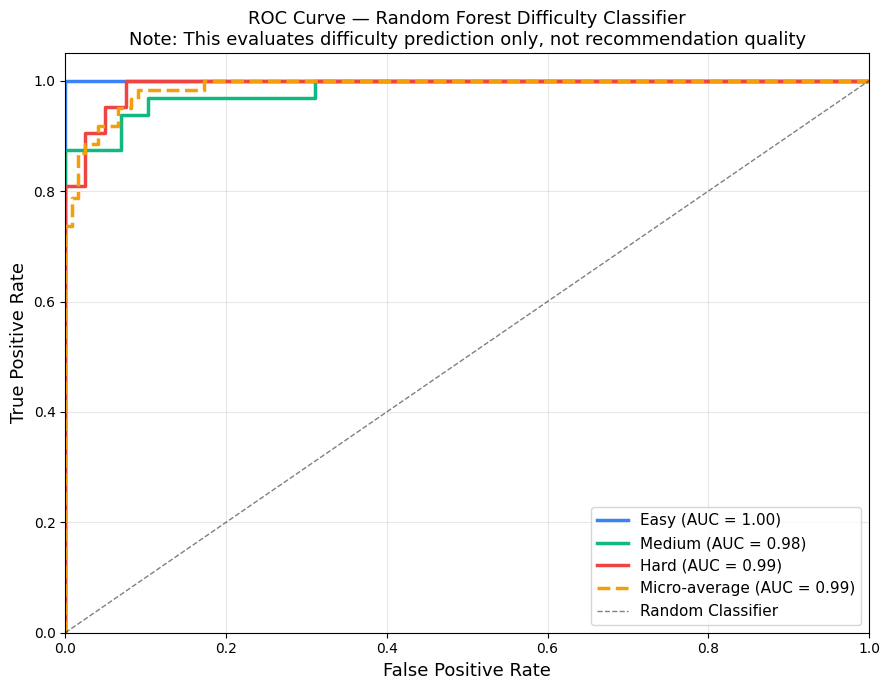


AUC Scores:
  Easy: 1.0000
  Medium: 0.9828
  Hard: 0.9917
  Micro-average: 0.9887


In [291]:
# ROC Curve for Random Forest Difficulty Classifier
# ROC curve measures classifier performance per class
# AUC (Area Under Curve) closer to 1.0 = better classifier
# This evaluates the difficulty prediction model only
# NOT recommendation quality

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize the output for multiclass ROC
# Classes: 1=Easy, 2=Medium, 3=Hard
classes = [1, 2, 3]
class_names = ['Easy', 'Medium', 'Hard']

y_test_bin = label_binarize(y_test, classes=classes)
y_score = rf_best.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin.ravel(), y_score.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#3b82f6', '#10b981', '#ef4444']

for i, (cls, name) in enumerate(zip(classes, class_names)):
    ax.plot(
        fpr[i], tpr[i],
        color=colors[i],
        linewidth=2.5,
        label=f'{name} (AUC = {roc_auc[i]:.2f})'
    )

ax.plot(
    fpr["micro"], tpr["micro"],
    color='#f59e0b',
    linewidth=2.5,
    linestyle='--',
    label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})'
)

# Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title(
    'ROC Curve — Random Forest Difficulty Classifier\n'
    'Note: This evaluates difficulty prediction only, not recommendation quality',
    fontsize=13
)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../saved_models/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("AUC Scores:")
for i, name in enumerate(class_names):
    print(f"  {name}: {roc_auc[i]:.4f}")
print(f"  Micro-average: {roc_auc['micro']:.4f}")

In [292]:
# Check SMB machines in dataset
print("Machines with SMB in Vulnerability_Type:")
smb_vuln = df[df['Vulnerability_Type'].fillna('').str.contains('SMB', case=False)]
print(f"Count: {len(smb_vuln)}")
for _, r in smb_vuln.iterrows():
    print(f"  {r['Machine_Name']} | {r['Difficulty']} | {r['Attack_Category']}")

print()
print("Machines with SMB in Learning_Objectives:")
smb_obj = df[df['Learning_Objectives'].fillna('').str.contains('SMB', case=False)]
print(f"Count: {len(smb_obj)}")
for _, r in smb_obj.iterrows():
    print(f"  {r['Machine_Name']} | {r['Difficulty']} | {r['Attack_Category']}")

Machines with SMB in Vulnerability_Type:
Count: 10
  WestWild 1.1 | Medium | Network Exploitation
  Mercy | Hard | Network Exploitation
  Bravery | Hard | Network Exploitation
  Symfonos 1 | Medium | Network Exploitation
  Symfonos 2 | Hard | Network Exploitation
  Symfonos 4 | Medium | Network Exploitation
  DC-9 | Hard | Web Exploitation
  Symfonos 5 | Hard | Network Exploitation
  Photographer 1 | Medium | Mixed (Web + Network)
  Relevant 1 | Medium | Mixed (Web + Network)

Machines with SMB in Learning_Objectives:
Count: 10
  LazySysAdmin | Medium | Web Exploitation
  Kioptrix Level 1 | Easy | Network Exploitation
  Mercy | Hard | Network Exploitation
  Bravery | Hard | Network Exploitation
  Symfonos 1 | Medium | Network Exploitation
  Symfonos 2 | Hard | Network Exploitation
  Symfonos 4 | Medium | Network Exploitation
  DC-9 | Hard | Web Exploitation
  Symfonos 5 | Hard | Network Exploitation
  Photographer 1 | Medium | Mixed (Web + Network)


In [293]:
mask = (
    (df['Difficulty'] == 'Medium') &
    (df['Attack_Category'] == 'Web Exploitation') &
    (df['Learning_Objectives'].fillna('').str.contains('SQL Injection')) &
    (df['Learning_Objectives'].fillna('').str.contains('File Upload Exploitation'))
)
print(f"Medium Web machines with BOTH SQL Injection AND File Upload Exploitation: {mask.sum()}")
for name in df[mask]['Machine_Name'].tolist():
    print(f"  {name}")

Medium Web machines with BOTH SQL Injection AND File Upload Exploitation: 0


In [294]:
import subprocess
subprocess.run(['pip', 'install', 'requests', '--break-system-packages'], 
               capture_output=True)
print("requests installed")

requests installed


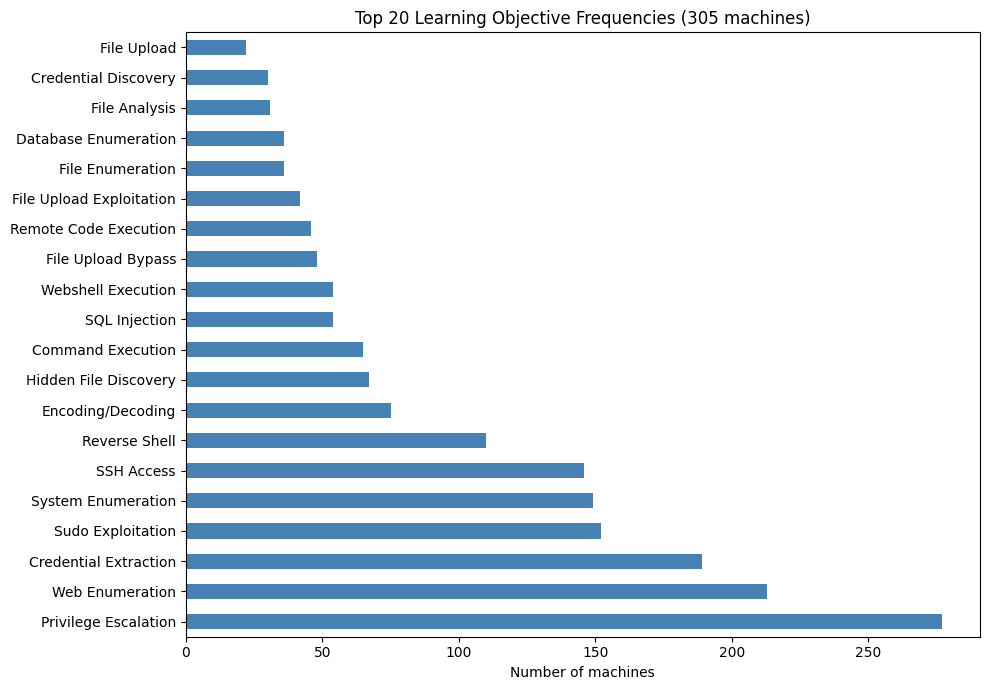

In [295]:
import matplotlib.pyplot as plt
import pandas as pd

all_objs = []
for s in df['Learning_Objectives'].dropna():
    all_objs.extend([o.strip() for o in s.split(';') if o.strip()])

obj_counts = pd.Series(all_objs).value_counts().head(20)

plt.figure(figsize=(10, 7))
obj_counts.plot(kind='barh', color='steelblue')
plt.xlabel('Number of machines')
plt.title('Top 20 Learning Objective Frequencies (305 machines)')
plt.tight_layout()
plt.savefig('learning_objective_frequency.png', dpi=120)
plt.show()

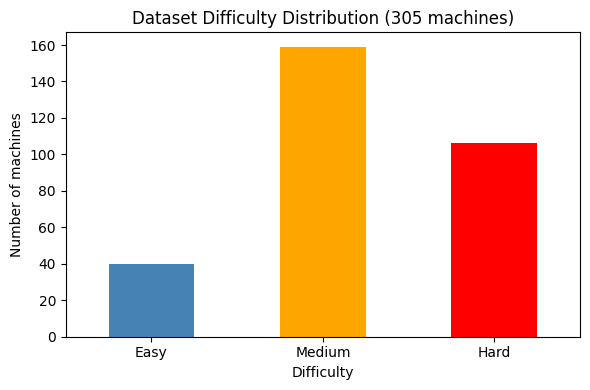

In [296]:
import matplotlib.pyplot as plt

counts = df['Difficulty'].value_counts()
plt.figure(figsize=(6,4))
counts = df['Difficulty'].value_counts().reindex(['Easy', 'Medium', 'Hard'])
counts.plot(kind='bar', color=['steelblue', 'orange', 'red'])
plt.title('Dataset Difficulty Distribution (305 machines)')
plt.ylabel('Number of machines')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('difficulty_distribution.png', dpi=120)
plt.show()

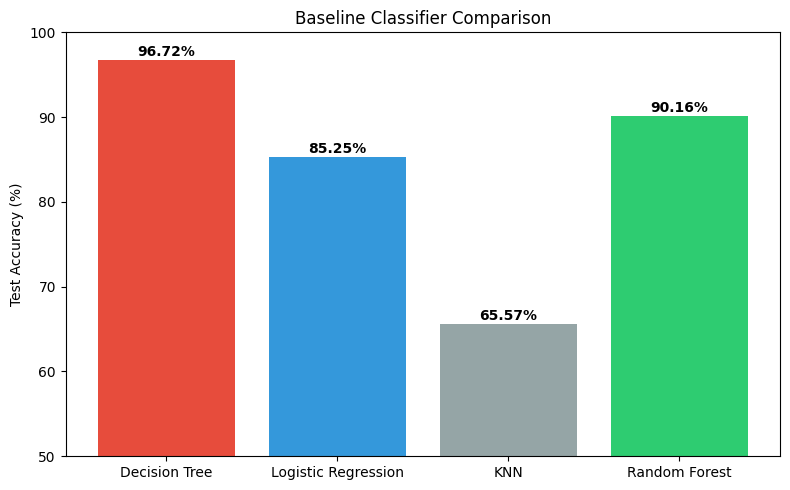

In [297]:
classifiers = ['Decision Tree', 'Logistic Regression', 'KNN', 'Random Forest']
accuracies = [96.72, 85.25, 65.57, 90.16]

plt.figure(figsize=(8,5))
plt.bar(classifiers, accuracies, color=['#e74c3c','#3498db','#95a5a6','#2ecc71'])
plt.ylabel('Test Accuracy (%)')
plt.title('Baseline Classifier Comparison')
plt.ylim(50, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('classifier_comparison.png', dpi=120)
plt.show()

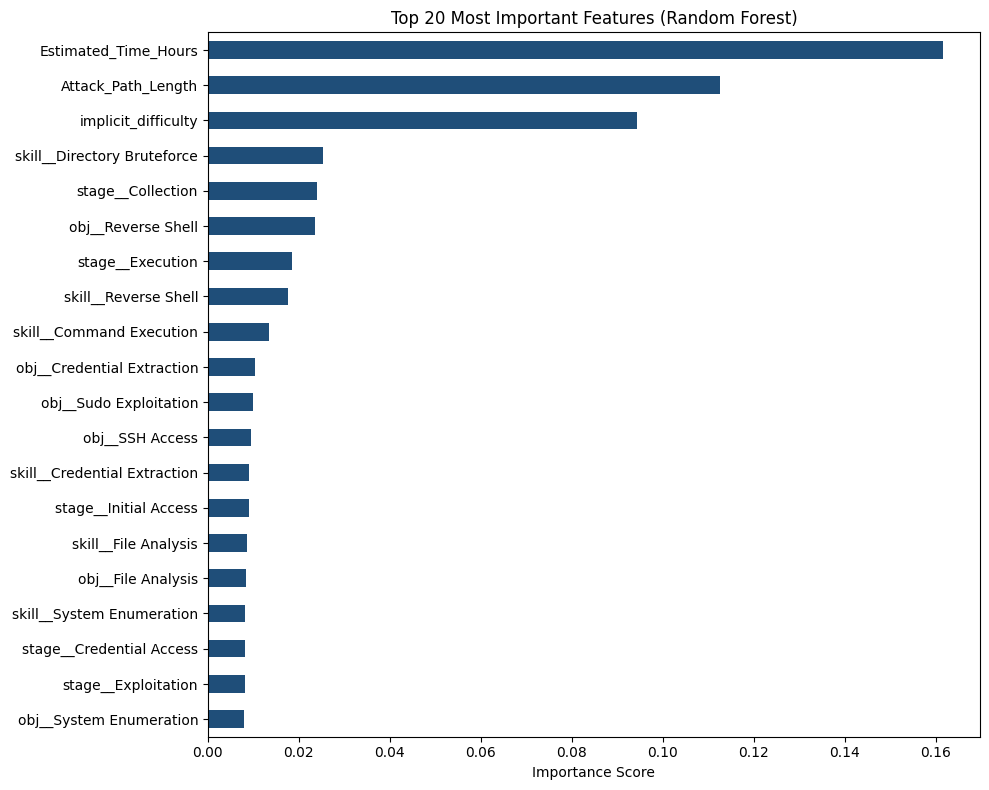

In [299]:
import matplotlib.pyplot as plt
import pandas as pd
import joblib

rf = joblib.load('../saved_models/random_forest.pkl')
X = joblib.load('../saved_models/feature_matrix.pkl')

importances = pd.Series(rf.feature_importances_, index=X.columns)
top20 = importances.nlargest(20).sort_values()

plt.figure(figsize=(10, 8))
top20.plot(kind='barh', color='#1F4E79')
plt.xlabel('Importance Score')
plt.title('Top 20 Most Important Features (Random Forest)')
plt.tight_layout()
plt.savefig('../saved_models/feature_importance_v1.png', dpi=120)
plt.show()